<div style="text-align:center; padding:40px 20px 30px 20px; border-top:3px solid #1f3a5f; border-bottom:3px solid #1f3a5f;">
  <p style="text-align:center; letter-spacing:2px; color:#5a6b7d; margin:0;">PROJET DE FIN D'ANNÉE — DATA SCIENCE</p>
  <h1 style="font-family:Georgia, serif; color:#1f3a5f; margin:18px 0 10px 0;">Modélisation de la probabilité de sinistre<br>en assurance automobile</h1>
  <p style="text-align:center; font-size:1.1em; color:#333; margin:0;">Analyse statistique, construction de classes de risque et comparaison de modèles de classification</p>
  <br>
  <p style="text-align:center; margin:0;"><b>Asma Allaigui</b></p>
  <p style="text-align:center; margin:0; color:#5a6b7d;">École Supérieure de la Statistique et de l'Analyse de l'Information (ESSAI) — Université de Carthage</p>
</div>

### Sommaire

1. Introduction
2. Problématique et objectifs
3. Présentation des données
4. Méthodologie
5. Environnement de travail
6. Chargement et contrôle qualité des données
7. Analyse exploratoire et tests statistiques
8. Sélection des variables
9. Construction des classes de risque
10. Choix des modalités de référence
11. Encodage et formulation du modèle logistique
12. Modélisation
13. Comparaison des modèles
14. Discussion et limites
15. Conclusion et perspectives

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">1. Introduction</h2>
</div>

En assurance non-vie, la tarification repose sur une estimation du **risque individuel** porté par chaque contrat. Pour un portefeuille automobile, ce risque se décompose classiquement en deux composantes : la **fréquence** des sinistres (l'assuré déclare-t-il un sinistre ?) et leur **sévérité** (quel en est le coût ?). La prime pure s'obtient comme le produit de ces deux quantités.

Ce projet porte sur la première composante. À partir des caractéristiques du contrat, de l'assuré, de sa zone géographique et de son véhicule, il s'agit d'estimer la **probabilité qu'une police donne lieu à un sinistre** sur la période d'observation.

L'enjeu est double :

- **Actuariel** : segmenter le portefeuille en classes de risque homogènes et justifier une différenciation tarifaire par des facteurs identifiables et interprétables ;
- **Opérationnel** : disposer d'un score permettant de cibler les profils à surveiller (souscription, prévention, gestion des sinistres).

La démarche suivie combine l'approche actuarielle classique (tests d'association, discrétisation des variables, régression logistique avec modalités de référence) et des méthodes d'apprentissage automatique ensemblistes (Random Forest, XGBoost), afin de confronter interprétabilité et performance prédictive.

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">2. Problématique et objectifs</h2>
</div>

### Question de recherche

> **Dans quelle mesure les caractéristiques d'un contrat, de l'assuré et de son véhicule permettent-elles de prédire la survenance d'un sinistre, et quels facteurs expliquent les écarts de risque entre assurés ?**

### Difficultés identifiées

| Difficulté | Conséquence pour la modélisation |
| :--- | :--- |
| **Déséquilibre de classes** : environ 6,4 % de polices sinistrées | L'exactitude (*accuracy*) n'est pas pertinente ; il faut privilégier l'AUC-ROC et corriger le déséquilibre lors de l'apprentissage |
| **Signal individuel faible** : aucune variable ne sépare nettement les deux classes | Le pouvoir prédictif doit venir de la combinaison de plusieurs facteurs |
| **Variables hétérogènes** : continues, binaires, catégorielles, textuelles | Nécessité d'un prétraitement et de tests adaptés à chaque type |
| **Exigence d'interprétabilité** propre au contexte actuariel | Le modèle de référence doit produire des effets lisibles (coefficients, *odds ratios*) |

### Objectifs

1. Identifier, par des tests statistiques adaptés, les variables significativement associées à la survenance d'un sinistre.
2. Construire des classes de risque stables et interprétables pour les variables retenues.
3. Estimer une régression logistique pénalisée et interpréter les effets de chaque classe par rapport à une modalité de référence.
4. Comparer ses performances à celles de deux modèles ensemblistes (Random Forest et XGBoost).

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">3. Présentation des données</h2>
</div>

Le jeu de données est un portefeuille de contrats d'assurance automobile (source : Kaggle). Chaque ligne correspond à une police, identifiée par `policy_id`.

| Caractéristique | Valeur |
| :--- | :--- |
| Nombre d'observations | 58 592 polices |
| Nombre de variables | 41 (28 textuelles, 13 numériques) |
| Valeurs manquantes | Aucune |
| Variable cible | `claim_status` : 1 si la police a été sinistrée, 0 sinon |

Les variables explicatives se répartissent en quatre familles :

| Famille | Exemples de variables |
| :--- | :--- |
| **Contrat** | `subscription_length` (ancienneté du contrat) |
| **Assuré et zone géographique** | `customer_age`, `region_code`, `region_density` |
| **Caractéristiques techniques du véhicule** | `vehicle_age`, `model`, `segment`, `fuel_type`, `cylinder`, `max_power`, `max_torque`, `length`, `width`, `gross_weight` |
| **Équipements de sécurité et de confort** | `airbags`, `is_esc`, `is_brake_assist`, `is_adjustable_steering`, `is_front_fog_lights`, `is_driver_seat_height_adjustable`, `ncap_rating`… |

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">4. Méthodologie</h2>
</div>

La démarche suit un enchaînement en six étapes, chacune alimentant la suivante.

| Étape | Contenu | Livrable |
| :---: | :--- | :--- |
| **1** | Chargement, contrôle qualité, analyse de la variable cible | Diagnostic du déséquilibre |
| **2** | Prétraitement exploratoire (extraction numérique, encodage provisoire) et tests d'association | Classement des variables par force de lien avec la cible |
| **3** | Sélection des variables : croisement des corrélations, des tests et de la pertinence métier | Liste de 11 variables retenues |
| **4** | Discrétisation et regroupement des modalités en classes de risque | Base `df_final` entièrement catégorielle |
| **5** | Choix des modalités de référence et encodage *one-hot* sans la référence | Matrice explicative `X` (25 colonnes) |
| **6** | Modélisation (régression logistique, XGBoost, Random Forest), optimisation par validation croisée et comparaison | Tableau comparatif et courbes ROC |

### Tests statistiques mobilisés

Le choix du test dépend du type de la variable explicative. La cible étant binaire, les tests retenus sont les suivants :

| Test | Type de variables | Hypothèse nulle H₀ | Mesure de l'intensité | Usage dans ce projet |
| :--- | :--- | :--- | :--- | :--- |
| **Chi² d'indépendance** | Catégorielle × cible | La variable et la cible sont indépendantes | V de Cramér (0 à 1) | Variables catégorielles et binaires |
| **Mann-Whitney U** | Continue × cible binaire | Les deux distributions sont identiques | Taille d'effet \|r\| (0 à 1) | Variables continues, sans hypothèse de normalité |
| **Kruskal-Wallis** | Continue × cible | Les distributions sont identiques entre groupes | Statistique H | Confirmation des résultats de Mann-Whitney |
| **Correction de Benjamini-Hochberg** | — | — | p-values ajustées | Contrôle du taux de fausses découvertes (tests multiples) |

**Remarque sur les grands échantillons.** Avec près de 60 000 observations, des écarts très faibles deviennent statistiquement significatifs. La p-value indique donc l'existence d'un lien, mais c'est la mesure d'intensité (V de Cramér, |r|) qui renseigne sur son importance pratique.

### Modèles et critères d'évaluation

- **Régression logistique pénalisée (L1/L2)** : modèle de référence, interprétable via les *odds ratios*.
- **Random Forest** et **XGBoost** : modèles ensemblistes capables de capter des interactions et des non-linéarités.
- Le déséquilibre est traité par pondération des classes (`class_weight="balanced"`, `scale_pos_weight`).
- Les hyperparamètres sont optimisés par **GridSearchCV** avec une validation croisée stratifiée à 5 plis, en maximisant l'**AUC-ROC**.
- L'évaluation finale est faite sur un échantillon test stratifié (30 %) : AUC-ROC (critère principal), Brier Score, MAE, MSE, RMSE et matrice de confusion.

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">5. Environnement de travail</h2>
</div>

Les bibliothèques utilisées couvrent la manipulation des données (`pandas`, `numpy`), la visualisation (`matplotlib`, `seaborn`), les tests statistiques (`scipy`, `statsmodels`) et la modélisation (`scikit-learn`, `xgboost`).

In [1]:
# ── Manipulation des données ─────────────────────────
import pandas as pd                        # Chargement, manipulation des DataFrames
import numpy as np                         # Calculs numériques, tableaux
 
# ── Visualisation ────────────────────────────────────
import matplotlib.pyplot as plt            # Graphiques de base
import matplotlib.ticker as mtick          # Formatage des axes (%, décimales)
import seaborn as sns                      # Visualisations statistiques avancées
CLR = {"low": "#2980b9", "high": "#c0392b", 0: "#4C72B0", 1: "#E05C2A"}
PALETTE_GRP = ["#2980b9", "#e67e22", "#c0392b", "#8e44ad"] 
# ── Tests_Statistiques ────────────────────────────────────
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
# ── Modelisation ────────────────────────────────────
from sklearn.linear_model  import LogisticRegression
from sklearn.metrics import roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline      import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics         import (mean_absolute_error, mean_squared_error,
                                     confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             roc_auc_score, brier_score_loss)



In [2]:
# ── Utilitaires ──────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")
 
# ── Configuration globale ────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 11, "axes.labelsize": 9})

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">6. Chargement et contrôle qualité des données</h2>
</div>

Le fichier est chargé puis dupliqué : `df_raw` conserve les valeurs d'origine et `df` sert aux transformations exploratoires. Un premier contrôle porte sur les dimensions, les valeurs manquantes, les types de colonnes et la distribution de la cible.

In [3]:
PATH   = "/kaggle/input/datasets/asmaallaigui/isurance-claims-copie/Insurance-claims-data-1copie.csv"
TARGET = "claim_status"

df_raw = pd.read_csv(PATH, sep=";")
df     = df_raw.copy()
print(f"Shape          : {df.shape}")
print(f"Valeurs nulles : {df.isnull().sum().sum()}")
print(f"\nDistribution cible :\n{df[TARGET].value_counts()}")
print(f"\nTaux de sinistre global : {df[TARGET].mean()*100:.2f}%")
print(f"\nTypes de colonnes :\n{df.dtypes.value_counts()}")

Shape          : (58592, 41)
Valeurs nulles : 0

Distribution cible :
claim_status
0    54844
1     3748
Name: count, dtype: int64

Taux de sinistre global : 6.40%

Types de colonnes :
object     28
int64      10
float64     3
Name: count, dtype: int64


In [4]:
df.head()


,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> La base est complète (aucune valeur manquante) et compte 58 592 polices pour 41 variables. Le taux de sinistre global est de **6,40 %** (3 748 polices sinistrées), ce qui confirme un fort déséquilibre de classes.
</div>

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">7. Analyse exploratoire et tests statistiques</h2>
</div>

### 7.1 Distribution de la variable cible

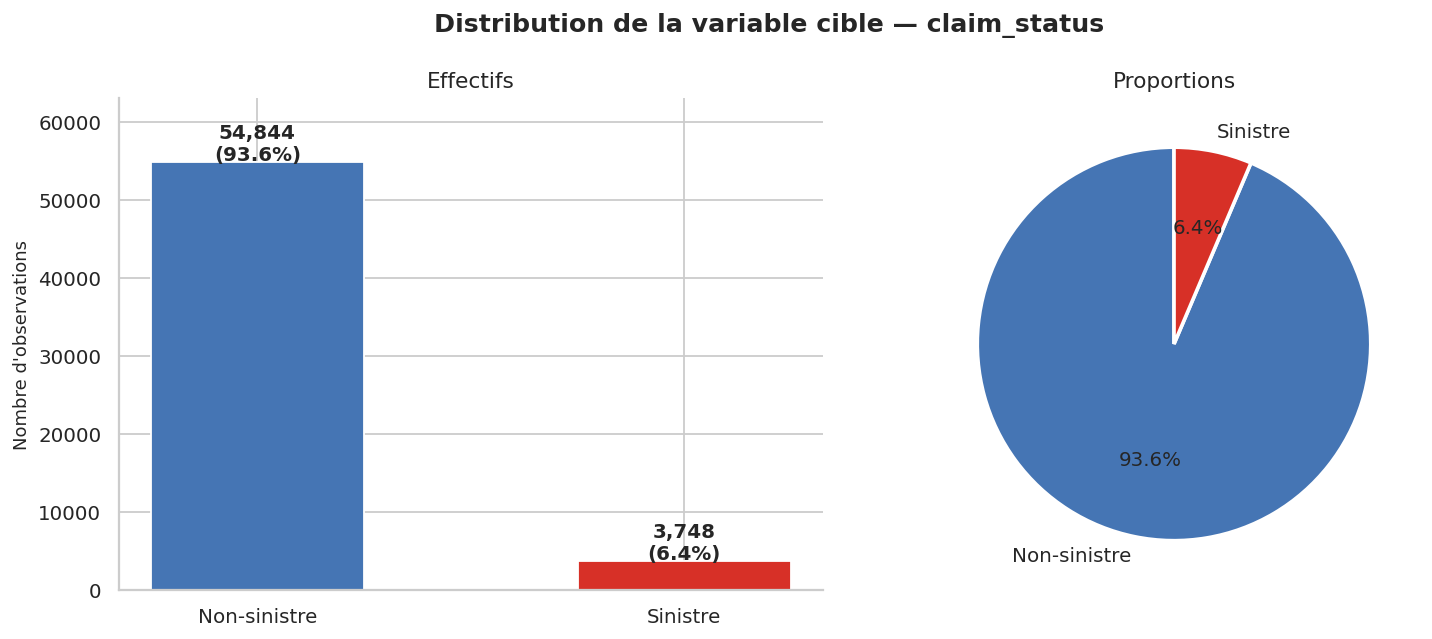

In [5]:
# ── DISTRIBUTION DE LA VARIABLE CIBLE : claim_status ─────────────
counts     = df[TARGET].value_counts()
pcts       = df[TARGET].value_counts(normalize=True) * 100
labels_map = {0: "Non-sinistre", 1: "Sinistre"}
labels     = [labels_map[i] for i in counts.index]
colors     = ["#4575b4", "#d73027"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribution de la variable cible — claim_status",
             fontsize=14, fontweight="bold")
# ── Barplot ───────────────────────────────────────────────────────
bars = axes[0].bar(labels, counts.values, color=colors, width=0.5)
for bar, val, pct in zip(bars, counts.values, pcts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 200,
                 f"{val:,}\n({pct:.1f}%)",
                 ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Effectifs", fontsize=12)
axes[0].set_ylabel("Nombre d'observations", fontsize=10)
axes[0].set_ylim(0, counts.max() * 1.15)
axes[0].spines[["top", "right"]].set_visible(False)

# ── Camembert ─────────────────────────────────────────────────────
axes[1].pie(counts.values,
            labels=labels,
            colors=colors,
            autopct="%1.1f%%",
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2},
            textprops={"fontsize": 11})
axes[1].set_title("Proportions", fontsize=12)

plt.tight_layout()
plt.show()


Le rapport entre les deux classes est d'environ **1 sinistre pour 14,6 non-sinistres**. Un modèle naïf prédisant systématiquement « pas de sinistre » atteindrait une exactitude de 93,6 % sans aucune valeur prédictive. Ce constat justifie l'usage de l'AUC-ROC comme critère principal et la pondération des classes lors de l'apprentissage.

### 7.2 Prétraitement exploratoire

Avant de mesurer les liens avec la cible, deux transformations sont appliquées sur la copie de travail `df` :

- **Extraction numérique** : `max_power` et `max_torque` sont stockées sous forme textuelle (par exemple `88.50bhp@6000rpm`). On extrait la valeur numérique principale.
- **Encodage provisoire** : les variables `Yes`/`No` sont converties en 1/0 et les autres variables textuelles font l'objet d'un *label encoding*. Cet encodage sert uniquement au calcul des corrélations ; l'encodage utilisé pour la modélisation est construit plus loin (section 11).

In [6]:
#BLOC 1 — Extraction de valeurs numériques depuis du texte
def extract_numeric(series: pd.Series) -> pd.Series:
    """Extrait la valeur numérique avant le '@' dans une colonne texte."""
    return (series
            .str.extract(r"([\d.]+)", expand=False)
            .astype(float))

df["max_power_val"]  = extract_numeric(df_raw["max_power"])
df["max_torque_val"] = extract_numeric(df_raw["max_torque"])

print(df[["max_power_val", "max_torque_val"]].describe().round(2))
print(f"\nNulls max_power_val  : {df['max_power_val'].isnull().sum()}")
print(f"Nulls max_torque_val : {df['max_torque_val'].isnull().sum()}")

       max_power_val  max_torque_val
count       58592.00        58592.00
mean           78.98          134.45
std            27.70           73.15
min            40.36           60.00
25%            40.36           60.00
50%            88.50          113.00
75%            97.89          200.00
max           118.36          250.00

Nulls max_power_val  : 0
Nulls max_torque_val : 0


In [7]:
#BLOC 2 — Encodage minimal pour calculer les corrélations
# ── Encodage + corrélations ───────────────────────────────────────────────────
EXCLUDE  = ["policy_id", "max_torque", "max_power", "engine_type"]

# Yes/No → 0/1
binary_cols = [c for c in df.columns if df[c].dropna().isin(["Yes","No"]).all()]
df[binary_cols] = df[binary_cols].replace({"Yes":1, "No":0})

# Catégorielles textuelles → label encoding
for c in df.select_dtypes("object").columns.difference(EXCLUDE):
    df[c] = df[c].astype("category").cat.codes

# Corrélation — numériques uniquement (exclut Interval/_bin et colonnes brutes)
corr_series = (df.drop(columns=EXCLUDE, errors="ignore")
                 .select_dtypes(include=[np.number])
                 .corr()[TARGET]
                 .drop(TARGET)
                 .abs()
                 .sort_values(ascending=False))

TOP15 = corr_series.head(15).index.tolist()
print(f"max_power_val  : {corr_series.get('max_power_val',  'ABSENTE')}")
print(f"max_torque_val : {corr_series.get('max_torque_val', 'ABSENTE')}")
print(f"\nTOP 10 :\n{corr_series.head(10).round(4).to_string()}")


max_power_val  : 0.007697556553227834
max_torque_val : 0.004294116251361297

TOP 10 :
subscription_length                 0.0787
vehicle_age                         0.0282
customer_age                        0.0222
region_density                      0.0178
is_adjustable_steering              0.0139
cylinder                            0.0134
is_front_fog_lights                 0.0118
is_brake_assist                     0.0109
is_driver_seat_height_adjustable    0.0107
width                               0.0099


<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> Les corrélations linéaires avec la cible sont toutes très faibles : la plus élevée, celle de `subscription_length`, vaut **0,079**. Aucune variable ne suffit seule à expliquer la sinistralité ; les tests suivants permettent de confirmer quels liens sont statistiquement établis malgré leur faible intensité.
</div>

### 7.3 Variables catégorielles : test du Chi² et V de Cramér

Pour chaque variable catégorielle (au plus 20 modalités), on construit le tableau de contingence avec `claim_status` et on applique le test du Chi² d'indépendance. Le **V de Cramér** normalise la statistique du Chi² pour mesurer l'intensité du lien, indépendamment de la taille de l'échantillon :

$$V = \sqrt{\frac{\chi^2}{n \cdot \min(r-1,\ c-1)}}$$

**Règle de lecture.** Une variable est jugée significativement liée à la cible si *p-value* < 0,05. Le V de Cramér sert ensuite à hiérarchiser les variables significatives.

In [8]:
# Test_Statistique: Chi² + Cramér's V (catégorielles vs target) ──────────────────
CONTINUOUS = ["subscription_length", "vehicle_age", "customer_age",
              "region_density", "max_power_val", "max_torque_val"]
cat_feats = [c for c in df.select_dtypes(include=[np.number]).columns
             if c not in CONTINUOUS + [TARGET] and df[c].nunique() <= 20]

rows = []
for feat in cat_feats:
    ct           = pd.crosstab(df[feat], df[TARGET])
    chi2, p, dof, _ = chi2_contingency(ct)
    n, k         = ct.values.sum(), min(ct.shape) - 1
    cramers_v    = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    rows.append({"Variable": feat, "p-value": round(p, 4),
                 "Cramér V": round(cramers_v, 4)})

chi_df = (pd.DataFrame(rows)
            .sort_values("Cramér V", ascending=False)
            .reset_index(drop=True))
chi_df["Significatif"] = chi_df["p-value"].lt(0.05).map({True:"Oui", False:"Non"})
print(chi_df.to_string(index=False))

                        Variable  p-value  Cramér V Significatif
                           model   0.0295    0.0185          Oui
                    displacement   0.0129    0.0182          Oui
                           width   0.0221    0.0182          Oui
                    gross_weight   0.0221    0.0182          Oui
                          length   0.0199    0.0176          Oui
                  turning_radius   0.0860    0.0154          Non
                         segment   0.0274    0.0147          Oui
          is_adjustable_steering   0.0008    0.0138          Oui
                        cylinder   0.0012    0.0134          Oui
             is_front_fog_lights   0.0044    0.0118          Oui
                 is_brake_assist   0.0088    0.0108          Oui
is_driver_seat_height_adjustable   0.0102    0.0106          Oui
                       fuel_type   0.0561    0.0099          Non
                   steering_type   0.0568    0.0099          Non
              is_parking_

<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> 12 variables sur 31 sont significativement liées à la cible au seuil de 5 %, notamment des caractéristiques du véhicule (`model`, `displacement`, `width`, `length`, `segment`, `cylinder`) et certains équipements (`is_adjustable_steering`, `is_brake_assist`, `is_front_fog_lights`, `is_driver_seat_height_adjustable`). Les V de Cramér restent toutefois inférieurs à 0,02 : ces associations sont réelles mais faibles individuellement. Des variables comme `airbags`, `ncap_rating` ou `transmission_type` ne présentent aucun lien significatif.
</div>

### 7.4 Variables continues : test de Mann-Whitney U

Les variables continues ne suivant pas une loi normale, on utilise le test non paramétrique de **Mann-Whitney U**, qui compare les distributions entre polices sinistrées et non sinistrées. La taille d'effet est calculée par la corrélation rang-bisériale :

$$r = 1 - \frac{2U}{n_0 \cdot n_1}$$

Six tests étant réalisés simultanément, les p-values sont ajustées par la **méthode de Benjamini-Hochberg** afin de limiter les faux positifs. Une variable est retenue si sa p-value corrigée est inférieure à 0,05.

In [9]:
# Test_Statistique: Normalité + Mann-Whitney (continues vs target) ────────────────
CONTINUOUS = ["subscription_length", "vehicle_age", "customer_age",
              "region_density", "max_power_val", "max_torque_val"]

rows = []
for feat in CONTINUOUS:
    g0, g1  = df.loc[df[TARGET]==0, feat].dropna(), df.loc[df[TARGET]==1, feat].dropna()
    stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
    r       = 1 - (2 * stat) / (len(g0) * len(g1))          # effect size
    rows.append({"Variable": feat, "p-value": p, "Effect size |r|": round(abs(r), 4)})

mw_df = pd.DataFrame(rows)
_, p_corr, _, _ = multipletests(mw_df["p-value"], method="fdr_bh")
mw_df["p-corrigé (BH)"] = p_corr.round(4)
mw_df["p-value"]        = mw_df["p-value"].round(4)
mw_df["Significatif"]   = mw_df["p-corrigé (BH)"].lt(0.05).map({True:"Oui", False:"Non"})
print(mw_df.sort_values("Effect size |r|", ascending=False).to_string(index=False))

           Variable  p-value  Effect size |r|  p-corrigé (BH) Significatif
subscription_length   0.0000           0.1819          0.0000          Oui
        vehicle_age   0.0000           0.0661          0.0000          Oui
       customer_age   0.0000           0.0498          0.0000          Oui
     region_density   0.0103           0.0248          0.0155          Oui
     max_torque_val   0.0826           0.0164          0.0992          Non
      max_power_val   0.1181           0.0148          0.1181          Non


<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> Quatre variables continues sont significatives après correction : `subscription_length` (|r| = 0,18, effet nettement le plus fort), `vehicle_age`, `customer_age` et `region_density`. La puissance (`max_power_val`) et le couple (`max_torque_val`) n'ont pas d'effet significatif sur la survenance d'un sinistre.
</div>

### 7.5 Confirmation : test de Kruskal-Wallis

Le test de Kruskal-Wallis généralise Mann-Whitney à plusieurs groupes. Avec une cible binaire, les deux tests sont équivalents : il est utilisé ici comme **contrôle de robustesse**, et pour afficher le sens des écarts à travers les moyennes de chaque groupe.

In [10]:
# ── Test de Kruskal-Wallis (variables continues vs target) ────────
from scipy.stats import kruskal

rows_kw = []
for feat in CONTINUOUS:
    grp0 = df.loc[df[TARGET] == 0, feat].dropna()
    grp1 = df.loc[df[TARGET] == 1, feat].dropna()
    stat, p = kruskal(grp0, grp1)
    rows_kw.append({
        "Variable"    : feat,
        "Moy. Non-sin": round(grp0.mean(), 3),
        "Moy. Sin"    : round(grp1.mean(), 3),
        "Écart"       : round(grp1.mean() - grp0.mean(), 3),
        "Stat H"      : round(stat, 3),
        "p-value"     : round(p, 4),
    })

kw_df = (pd.DataFrame(rows_kw)
           .sort_values("Stat H", ascending=False)
           .reset_index(drop=True))
kw_df["Significatif"] = kw_df["p-value"].lt(0.05).map({True: "Oui", False: "Non"})

print("═" * 75)
print("  KRUSKAL-WALLIS — Variables continues vs claim_status")
print("═" * 75)
print(kw_df.to_string(index=False))
print("═" * 75)

═══════════════════════════════════════════════════════════════════════════
  KRUSKAL-WALLIS — Variables continues vs claim_status
═══════════════════════════════════════════════════════════════════════════
           Variable  Moy. Non-sin  Moy. Sin     Écart  Stat H  p-value Significatif
subscription_length         6.026     7.359     1.333 348.261   0.0000          Oui
        vehicle_age         1.397     1.266    -0.131  46.142   0.0000          Oui
       customer_age        44.784    45.414     0.630  26.122   0.0000          Oui
     region_density     18909.073 17623.820 -1285.253   6.574   0.0103          Oui
     max_torque_val       134.369   135.652     1.284   3.012   0.0826          Non
      max_power_val        78.921    79.792     0.871   2.442   0.1181          Non
═══════════════════════════════════════════════════════════════════════════


<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> Les conclusions de Mann-Whitney sont confirmées. Les écarts de moyennes précisent le sens des effets : les polices sinistrées ont une **ancienneté de contrat plus élevée** (7,36 contre 6,03), des **véhicules légèrement plus récents** (1,27 contre 1,40 an), des **assurés légèrement plus âgés** (45,4 contre 44,8 ans) et se situent dans des **zones un peu moins denses**.
</div>

### 7.6 Classement des variables selon leur corrélation avec la cible

Le classement ci-dessous synthétise l'intensité du lien linéaire de chaque variable avec `claim_status`. Il sert de point de départ à la sélection de variables (section 8).

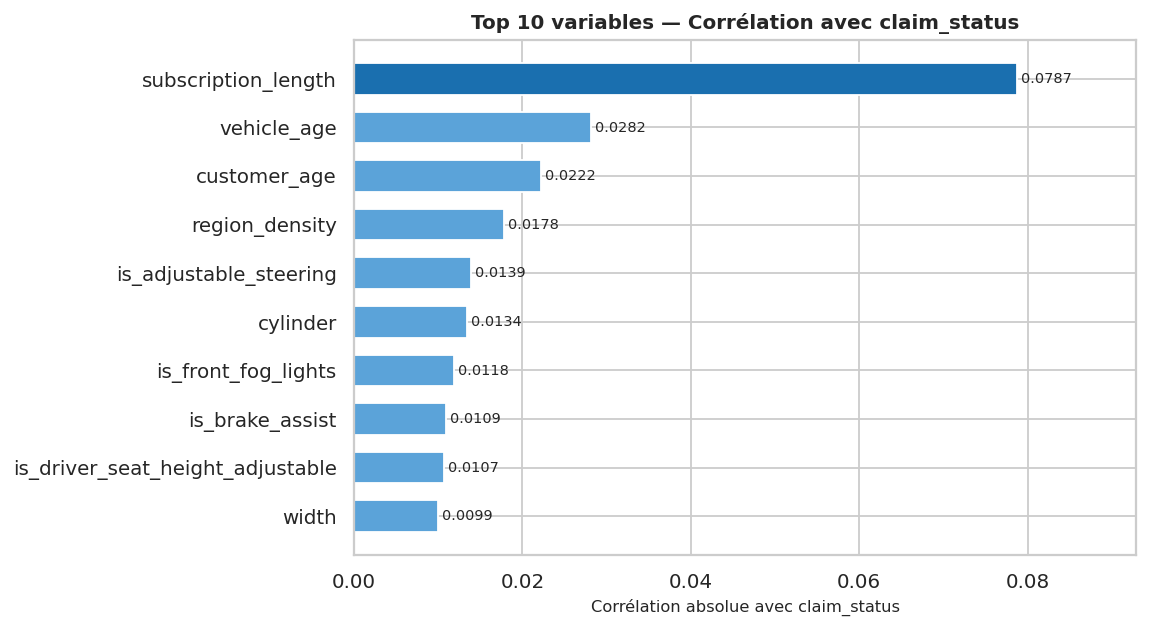

In [11]:
#  Visualisation des Top 10 corrélations
vals   = corr_series.head(10).values[::-1]
labels = corr_series.head(10).index[::-1]
colors = ["#1a6faf" if i == len(vals) - 1 else "#5ba3d9" for i in range(len(vals))]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, vals, color=colors, edgecolor="white", height=0.65)
for bar, v in zip(bars, vals):
    ax.text(v + 0.0005, bar.get_y() + bar.get_height() / 2,
            f"{v:.4f}", va="center", fontsize=8)
ax.set_xlabel("Corrélation absolue avec claim_status")
ax.set_title("Top 10 variables — Corrélation avec claim_status", fontweight="bold")
ax.set_xlim(0, max(vals) * 1.18)
plt.tight_layout()
plt.show()

### 7.7 Analyse bivariée des 15 variables les plus corrélées

Pour chacune des 15 variables en tête du classement, on compare la distribution entre polices sinistrées (`Claim=1`) et non sinistrées (`Claim=0`) : courbes de densité pour les variables continues, diagrammes en barres pour les variables catégorielles.

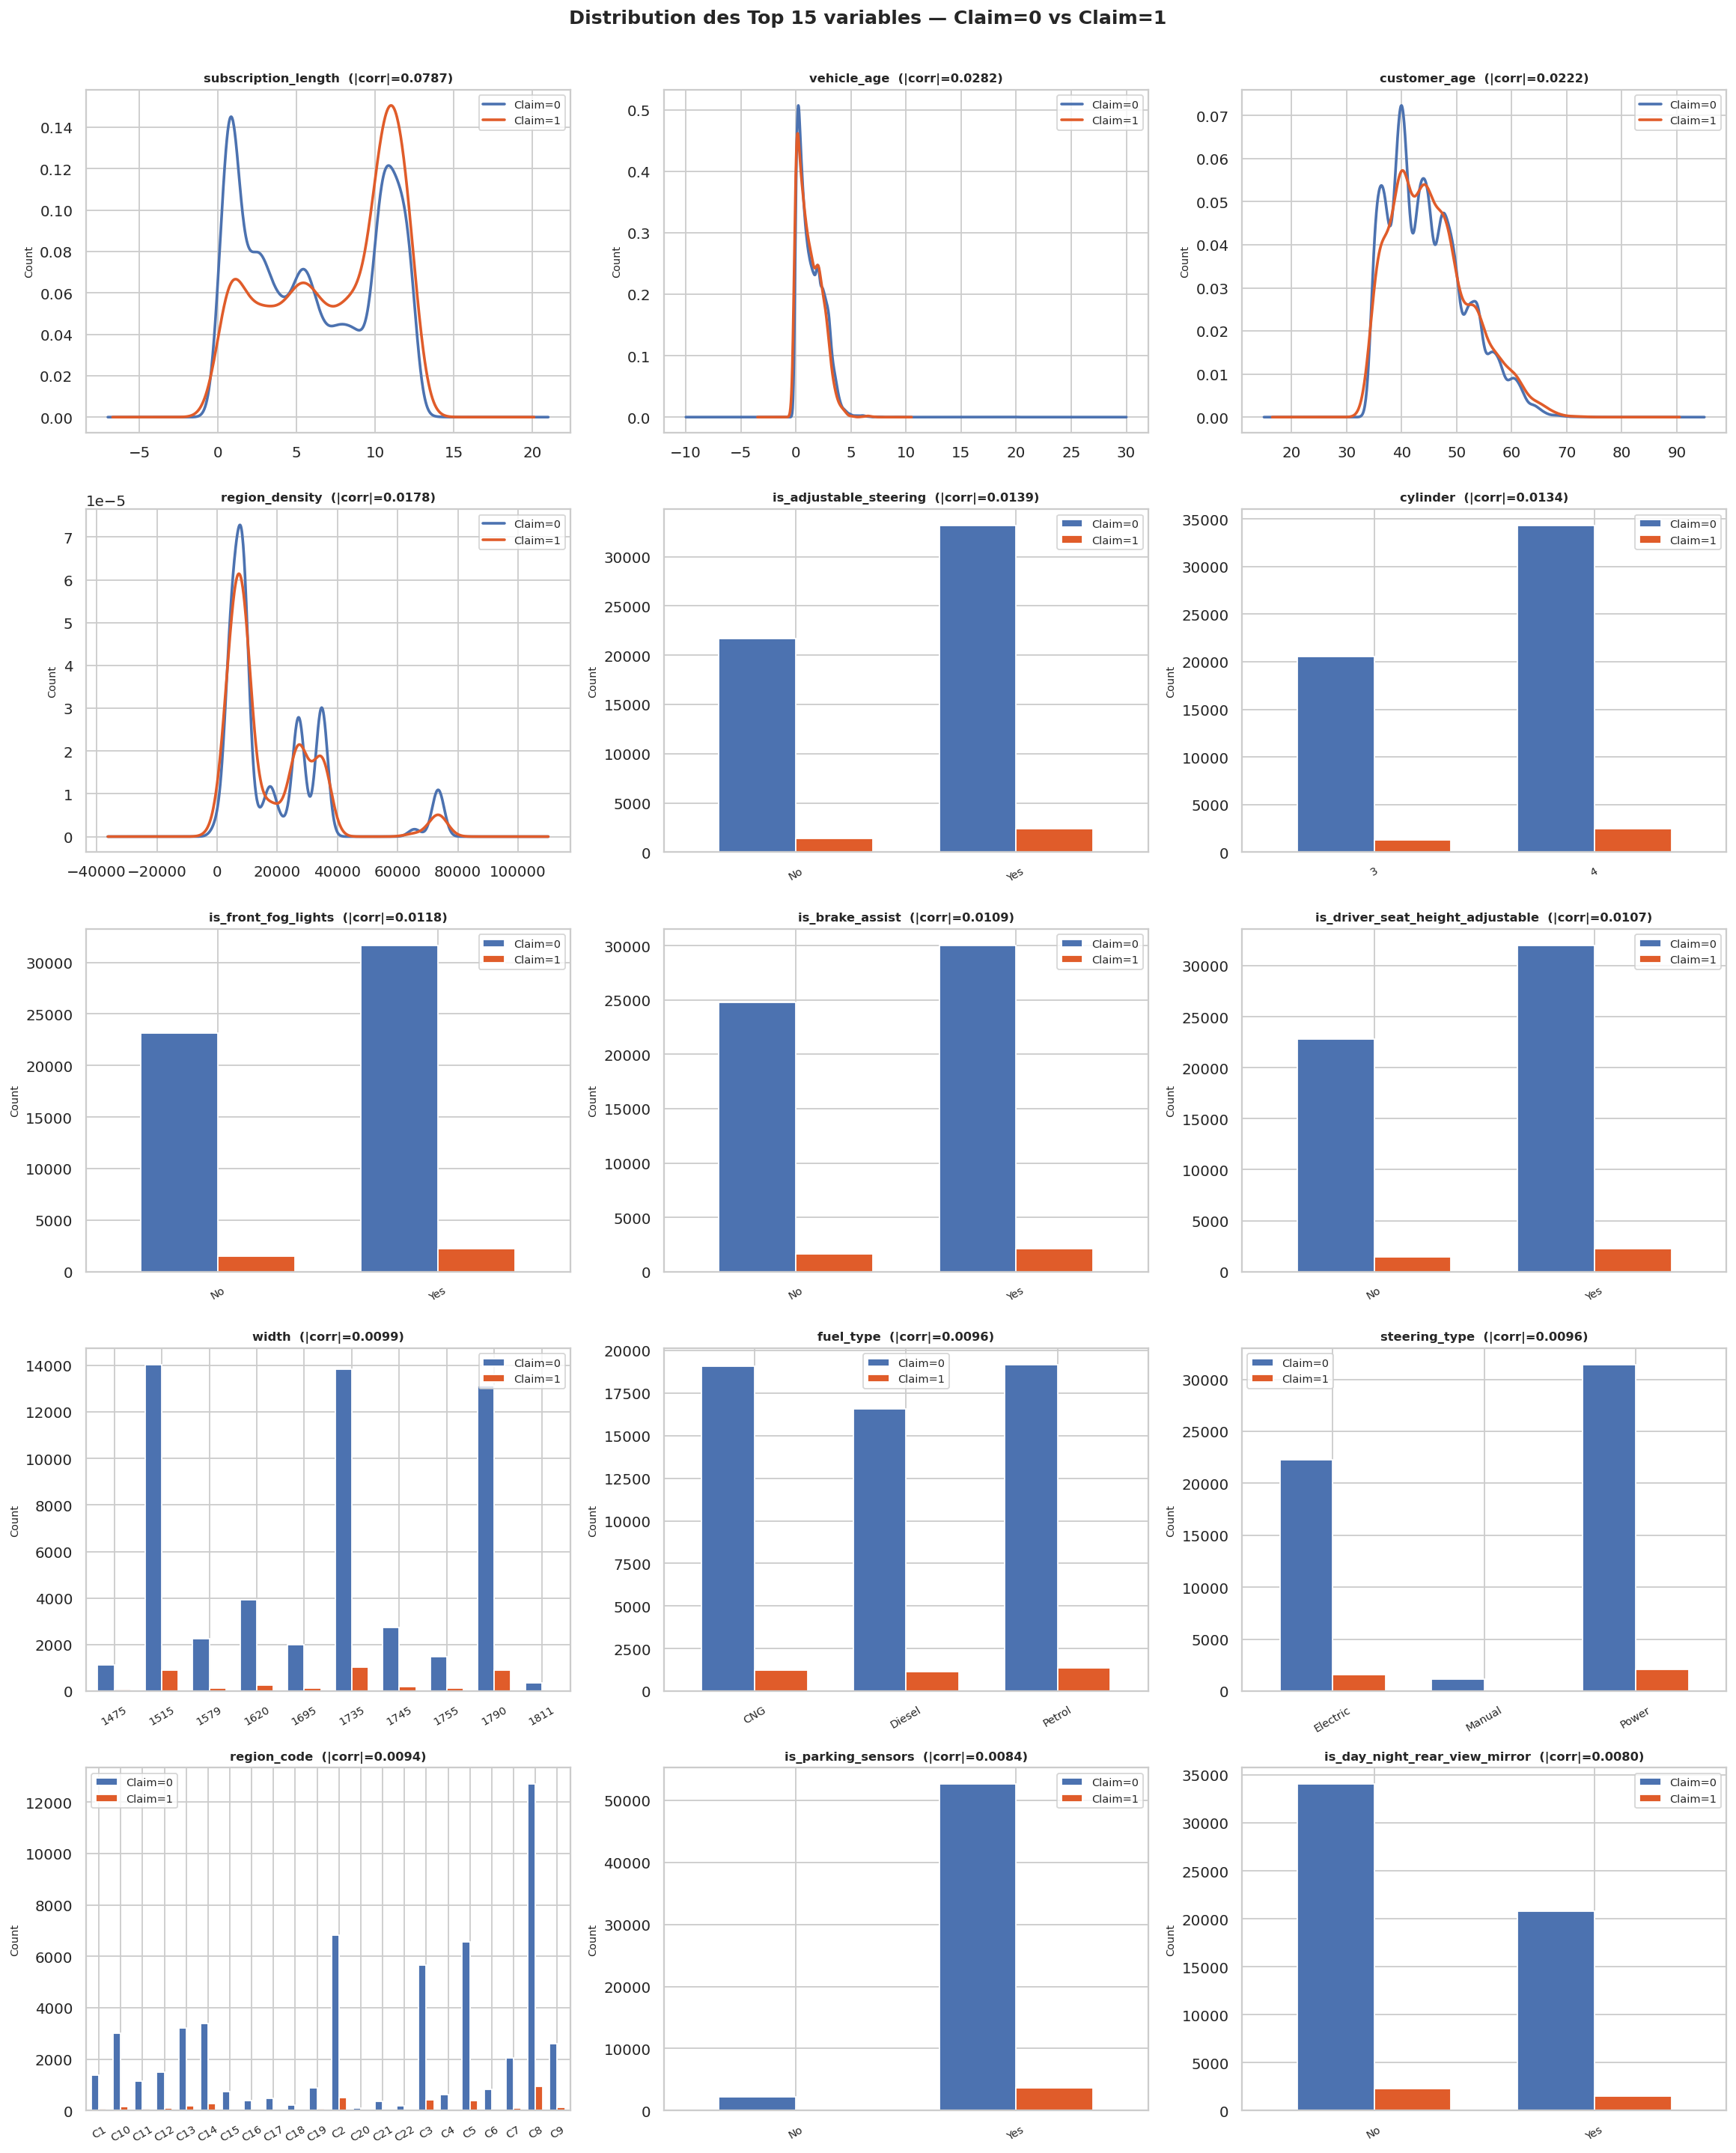

In [12]:
# BLOC 4 — Distribution Count(0) / Count(1) pour Ces variable 
CONTINUOUS        = ["subscription_length", "vehicle_age", "customer_age",
                     "region_density", "max_power_val", "max_torque_val"]
CATEGORICAL_TOP15 = [f for f in TOP15 if f not in CONTINUOUS]
def get_label_series(feat: str) -> pd.Series:
    """Retourne les labels originaux (avant encodage) pour une variable."""
    if feat in binary_cols:
        return df[feat].replace({1: "Yes", 0: "No"})
    if feat in ["fuel_type", "steering_type", "region_code"]:
        return df_raw[feat]
    return df[feat]

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for i, feat in enumerate(TOP15):
    ax   = axes[i]
    corr = corr_series[feat]
    if feat in CONTINUOUS:
        for cls, grp in df.groupby(TARGET):
            grp[feat].plot.kde(ax=ax, label=f"Claim={cls}",
                               color=CLR[cls], linewidth=2)
        ax.legend(fontsize=8)
    else:
        ct = pd.crosstab(get_label_series(feat), df[TARGET])
        ct.columns = ["Claim=0", "Claim=1"]
        ct.plot(kind="bar", ax=ax, color=[CLR[0], CLR[1]],
                edgecolor="white", width=0.70)
        ax.tick_params(axis="x", rotation=30, labelsize=8)
        ax.legend(fontsize=8)
    ax.set_title(f"{feat}  (|corr|={corr:.4f})", fontsize=9, fontweight="bold")
    ax.set_ylabel("Count", fontsize=8)
    ax.set_xlabel("")

for j in range(len(TOP15), len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Distribution des Top 15 variables — Claim=0 vs Claim=1",
             fontsize=14, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()
 

<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> Les distributions des deux classes se superposent largement, ce qui est cohérent avec les faibles tailles d'effet mesurées. Seule `subscription_length` montre un décalage visible vers les valeurs élevées chez les sinistrés. Comme souvent en actuariat, une variable isolée explique peu le risque : c'est la **combinaison** de plusieurs facteurs dans un modèle multivarié qui produit une segmentation utile.
</div>

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">8. Sélection des variables</h2>
</div>

La sélection croise trois sources d'information :

- **Intensité statistique** : les 10 variables les plus corrélées à la cible, toutes significatives d'après les tests de la section 7 ;
- **Pertinence métier** : ajout forcé de `region_code` (zonage géographique, facteur tarifaire classique en assurance automobile) et de `width` (gabarit du véhicule, significative au test du Chi²) ;
- **Parcimonie** : les variables non significatives ou redondantes sont écartées afin de limiter le bruit et la multicolinéarité.

Les variables retenues sont ensuite classées en quantitatives et qualitatives, ce qui détermine le traitement appliqué à chacune.

In [13]:
top10_vars = corr_series.head(10).index.tolist()
quantitative_vars = []
qualitative_vars  = []
 
force_quantitative = ['width']
force_qualitative  = ['region_code']
 
all_vars = top10_vars.copy()
for var in force_qualitative + force_quantitative:
    if var not in all_vars:
        all_vars.append(var)
 
for var in all_vars:
    if var in force_qualitative:
        qualitative_vars.append(var)
    elif var in force_quantitative:
        quantitative_vars.append(var)
    elif var in binary_cols:
        qualitative_vars.append(var)
    elif var in df_raw.select_dtypes(include='object').columns:
        qualitative_vars.append(var)
    elif df[var].nunique() > 10:          # ← df_enc remplacé par df
        quantitative_vars.append(var)
    else:
        qualitative_vars.append(var)
 
print("Variables QUANTITATIVES :", quantitative_vars)
print("Variables QUALITATIVES  :", qualitative_vars)

Variables QUANTITATIVES : ['subscription_length', 'vehicle_age', 'customer_age', 'region_density', 'width']
Variables QUALITATIVES  : ['is_adjustable_steering', 'cylinder', 'is_front_fog_lights', 'is_brake_assist', 'is_driver_seat_height_adjustable', 'region_code']


<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> **11 variables** sont retenues : 5 quantitatives (`subscription_length`, `vehicle_age`, `customer_age`, `region_density`, `width`) et 6 qualitatives (4 équipements binaires, `cylinder` et `region_code`).
</div>

### 8.1 Taux de sinistre par modalité — variables qualitatives

Pour chaque modalité, on calcule le nombre de polices non sinistrées, sinistrées et le **taux de sinistre**. Le graphique compare chaque taux à la moyenne du portefeuille (6,40 %) : les modalités en rouge sont plus risquées que la moyenne, celles en bleu le sont moins.

In [14]:
# BLOC 4 — Distribution Count(0) / Count(1) — Variables QUALITATIVES

def get_label_series(feat):
    if feat in binary_cols:
        return df[feat].replace({1: "Yes", 0: "No"})
    elif feat in df_raw.select_dtypes(include='object').columns:
        return df_raw[feat]
    else:
        return df[feat]

rows = []
for feat in qualitative_vars:
    ct = pd.crosstab(get_label_series(feat), df[TARGET], margins=True)
    ct.columns = ["Count_0", "Count_1", "Total"]
    ct["Taux_sinistre_%"] = (ct["Count_1"] / ct["Total"] * 100).round(2)
    ct.insert(0, "Variable", feat)
    rows.append(ct.rename_axis("Modalite").reset_index())

summary = pd.concat(rows, ignore_index=True)

(summary.style
        .background_gradient(subset=["Taux_sinistre_%"], cmap="RdYlBu_r")
        .format({"Count_0": "{:,}", "Count_1": "{:,}",
                 "Total": "{:,}", "Taux_sinistre_%": "{:.2f}%"})
        .set_properties(**{"text-align": "center", "font-size": "11px"})
        .set_table_styles([
            {"selector": "th", "props": [("font-weight", "bold"),
                                         ("text-align", "center")]},
        ])
        .set_caption("Taux de sinistre par modalité — Variables qualitatives"))

,Modalite,Variable,Count_0,Count_1,Total,Taux_sinistre_%
0,No,is_adjustable_steering,"21,688","1,378","23,066",5.97%
1,Yes,is_adjustable_steering,"33,156","2,370","35,526",6.67%
2,All,is_adjustable_steering,"54,844","3,748","58,592",6.40%
3,3,cylinder,"20,552","1,305","21,857",5.97%
4,4,cylinder,"34,292","2,443","36,735",6.65%
5,All,cylinder,"54,844","3,748","58,592",6.40%
6,No,is_front_fog_lights,"23,170","1,494","24,664",6.06%
7,Yes,is_front_fog_lights,"31,674","2,254","33,928",6.64%
8,All,is_front_fog_lights,"54,844","3,748","58,592",6.40%
9,No,is_brake_assist,"24,803","1,612","26,415",6.10%


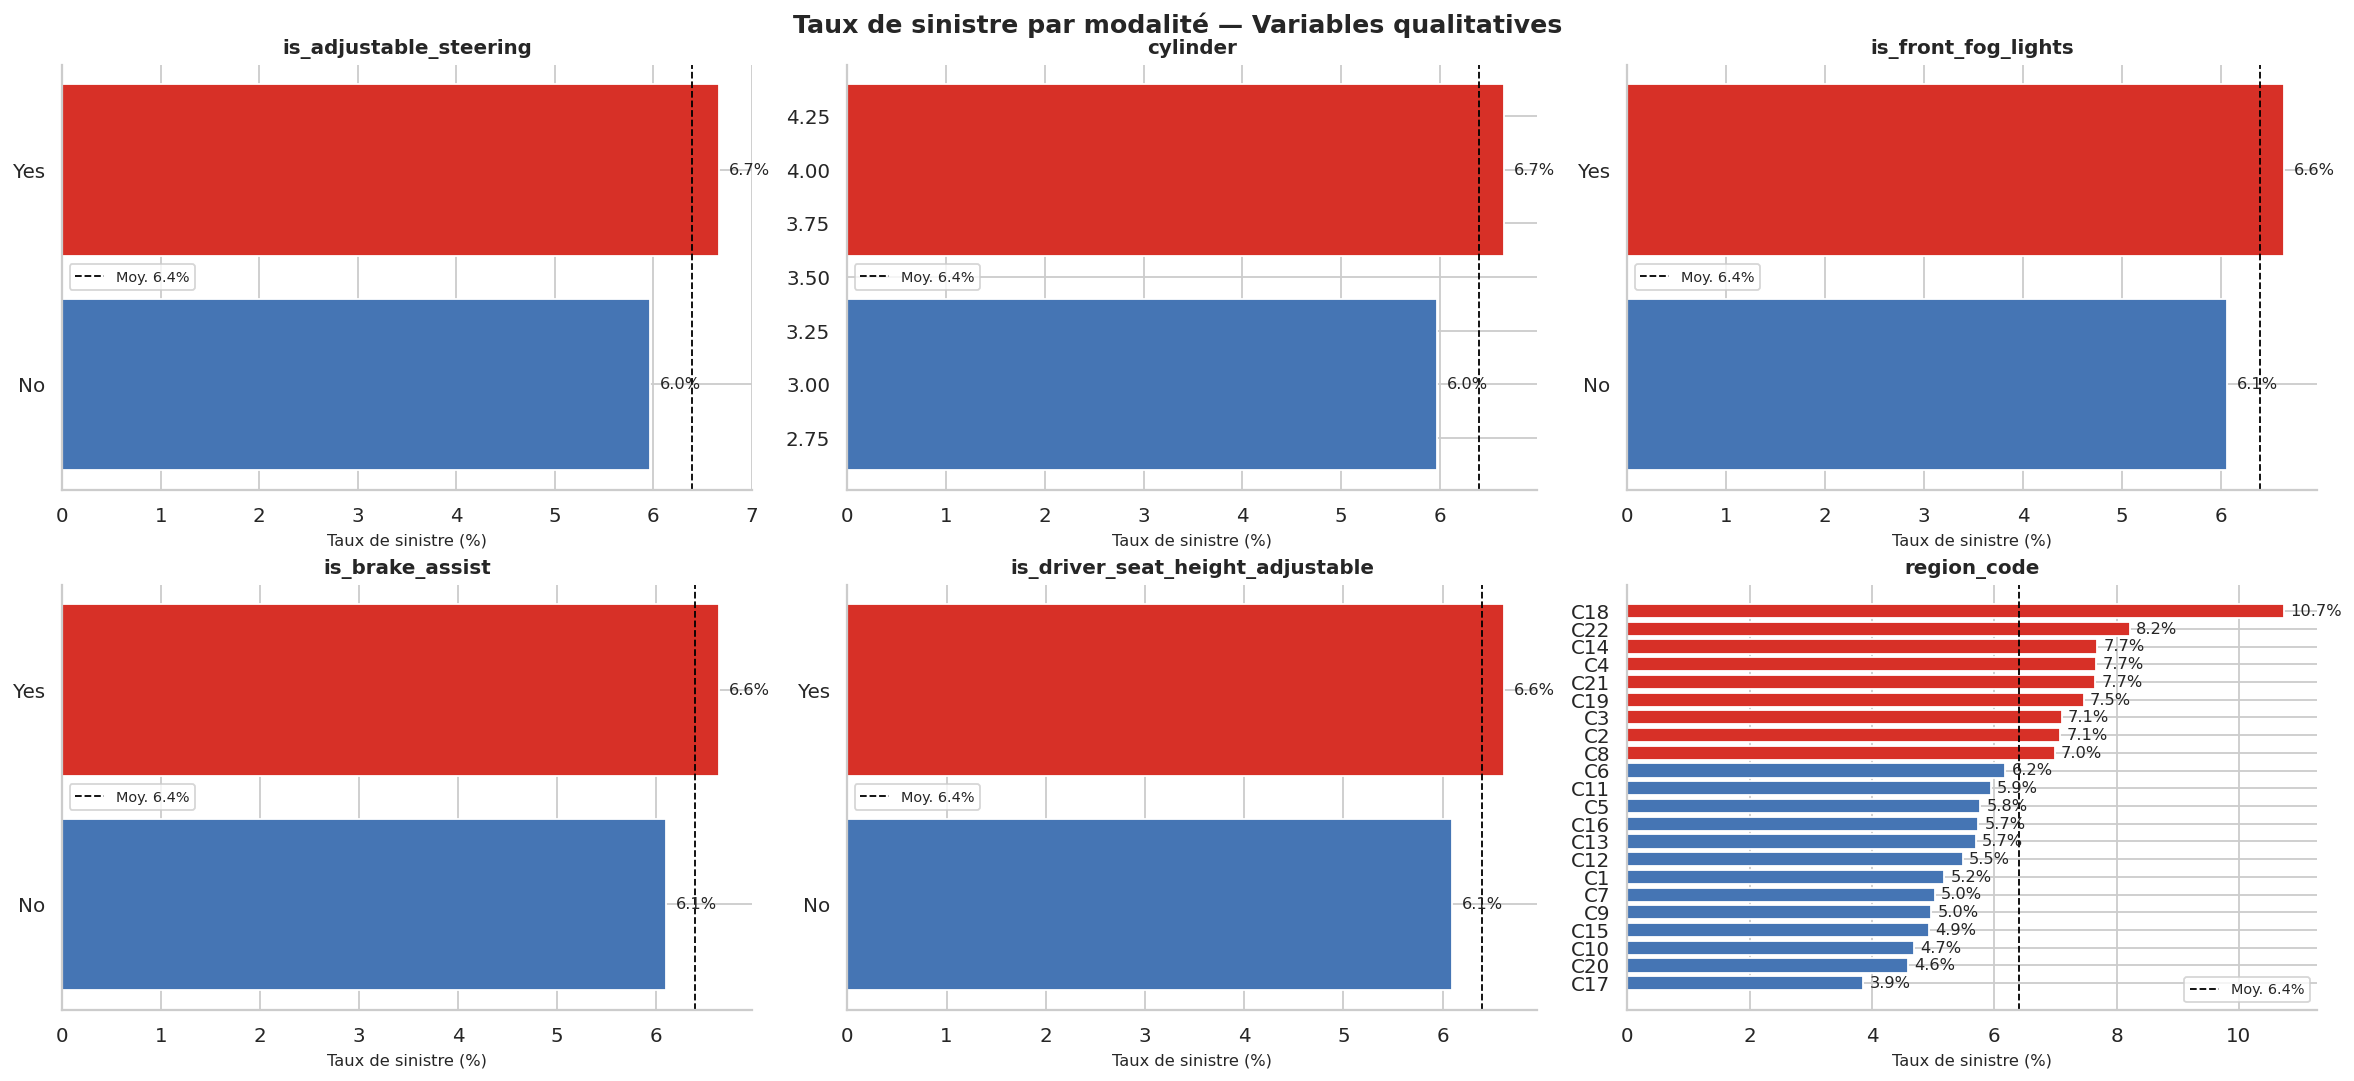

In [15]:
# ── FIGURE — Taux de sinistre par modalité ────────────────────
summary_plot = summary[summary["Modalite"] != "All"].copy()
mean_rate    = df[TARGET].mean() * 100
n_vars = len(qualitative_vars)
ncols  = 3
nrows  = -(-n_vars // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(18, nrows * 4),
                         constrained_layout=True)
axes = axes.flatten()
for i, feat in enumerate(qualitative_vars):
    ax   = axes[i]
    data = (summary_plot[summary_plot["Variable"] == feat]
            .sort_values("Taux_sinistre_%"))

    bars = ax.barh(data["Modalite"], data["Taux_sinistre_%"],
                   color=["#d73027" if v >= mean_rate else "#4575b4"
                          for v in data["Taux_sinistre_%"]])
    # ligne moyenne globale
    ax.axvline(mean_rate, color="black", linestyle="--",
               linewidth=1, label=f"Moy. {mean_rate:.1f}%")
    # valeurs sur les barres
    for bar, val in zip(bars, data["Taux_sinistre_%"]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=9)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel("Taux de sinistre (%)", fontsize=9)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
# masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Taux de sinistre par modalité — Variables qualitatives",
             fontsize=14, fontweight="bold", y=1.02)
plt.show()

### 8.2 Taux de sinistre par intervalle — variables quantitatives

Les variables quantitatives sont découpées en 10 intervalles de même amplitude. Ce découpage exploratoire permet de visualiser la forme de la relation avec le risque (monotone, en U, par paliers) et de préparer le regroupement en classes.

In [16]:
# BLOC 5 — Distribution Count(0) / Count(1) — Variables QUANTITATIVES (10 intervalles égaux)
rows_quant = []
for feat in quantitative_vars:
    df[f"{feat}_bin"] = pd.cut(df_raw[feat], bins=10)
    ct = pd.crosstab(df[f"{feat}_bin"].astype(str), df[TARGET], margins=True)
    ct.columns = ["Count_0", "Count_1", "Total"]
    ct["Taux_sinistre_%"] = (ct["Count_1"] / ct["Total"] * 100).round(2)
    ct.insert(0, "Variable", feat)
    rows_quant.append(ct.rename_axis("Intervalle").reset_index())

summary_quant = pd.concat(rows_quant, ignore_index=True)

(summary_quant.style
              .background_gradient(subset=["Taux_sinistre_%"], cmap="RdYlBu_r")
              .format({"Count_0": "{:,}", "Count_1": "{:,}",
                       "Total": "{:,}", "Taux_sinistre_%": "{:.2f}%"})
              .set_properties(**{"text-align": "center", "font-size": "11px"})
              .set_table_styles([
                  {"selector": "th", "props": [("font-weight", "bold"),
                                               ("text-align", "center")]},
              ])
              .set_caption("Taux de sinistre par intervalle — Variables quantitatives (7 intervalles égaux)"))

,Intervalle,Variable,Count_0,Count_1,Total,Taux_sinistre_%
0,"(-0.014, 1.4]",subscription_length,"11,517",431,"11,948",3.61%
1,"(1.4, 2.8]",subscription_length,"5,963",274,"6,237",4.39%
2,"(11.2, 12.6]",subscription_length,"7,493",684,"8,177",8.36%
3,"(12.6, 14.0]",subscription_length,18,2,20,10.00%
4,"(2.8, 4.2]",subscription_length,"4,719",256,"4,975",5.15%
5,"(4.2, 5.6]",subscription_length,"5,397",365,"5,762",6.33%
6,"(5.6, 7.0]",subscription_length,"4,142",304,"4,446",6.84%
7,"(7.0, 8.4]",subscription_length,"3,213",247,"3,460",7.14%
8,"(8.4, 9.8]",subscription_length,"3,050",317,"3,367",9.41%
9,"(9.8, 11.2]",subscription_length,"9,332",868,"10,200",8.51%


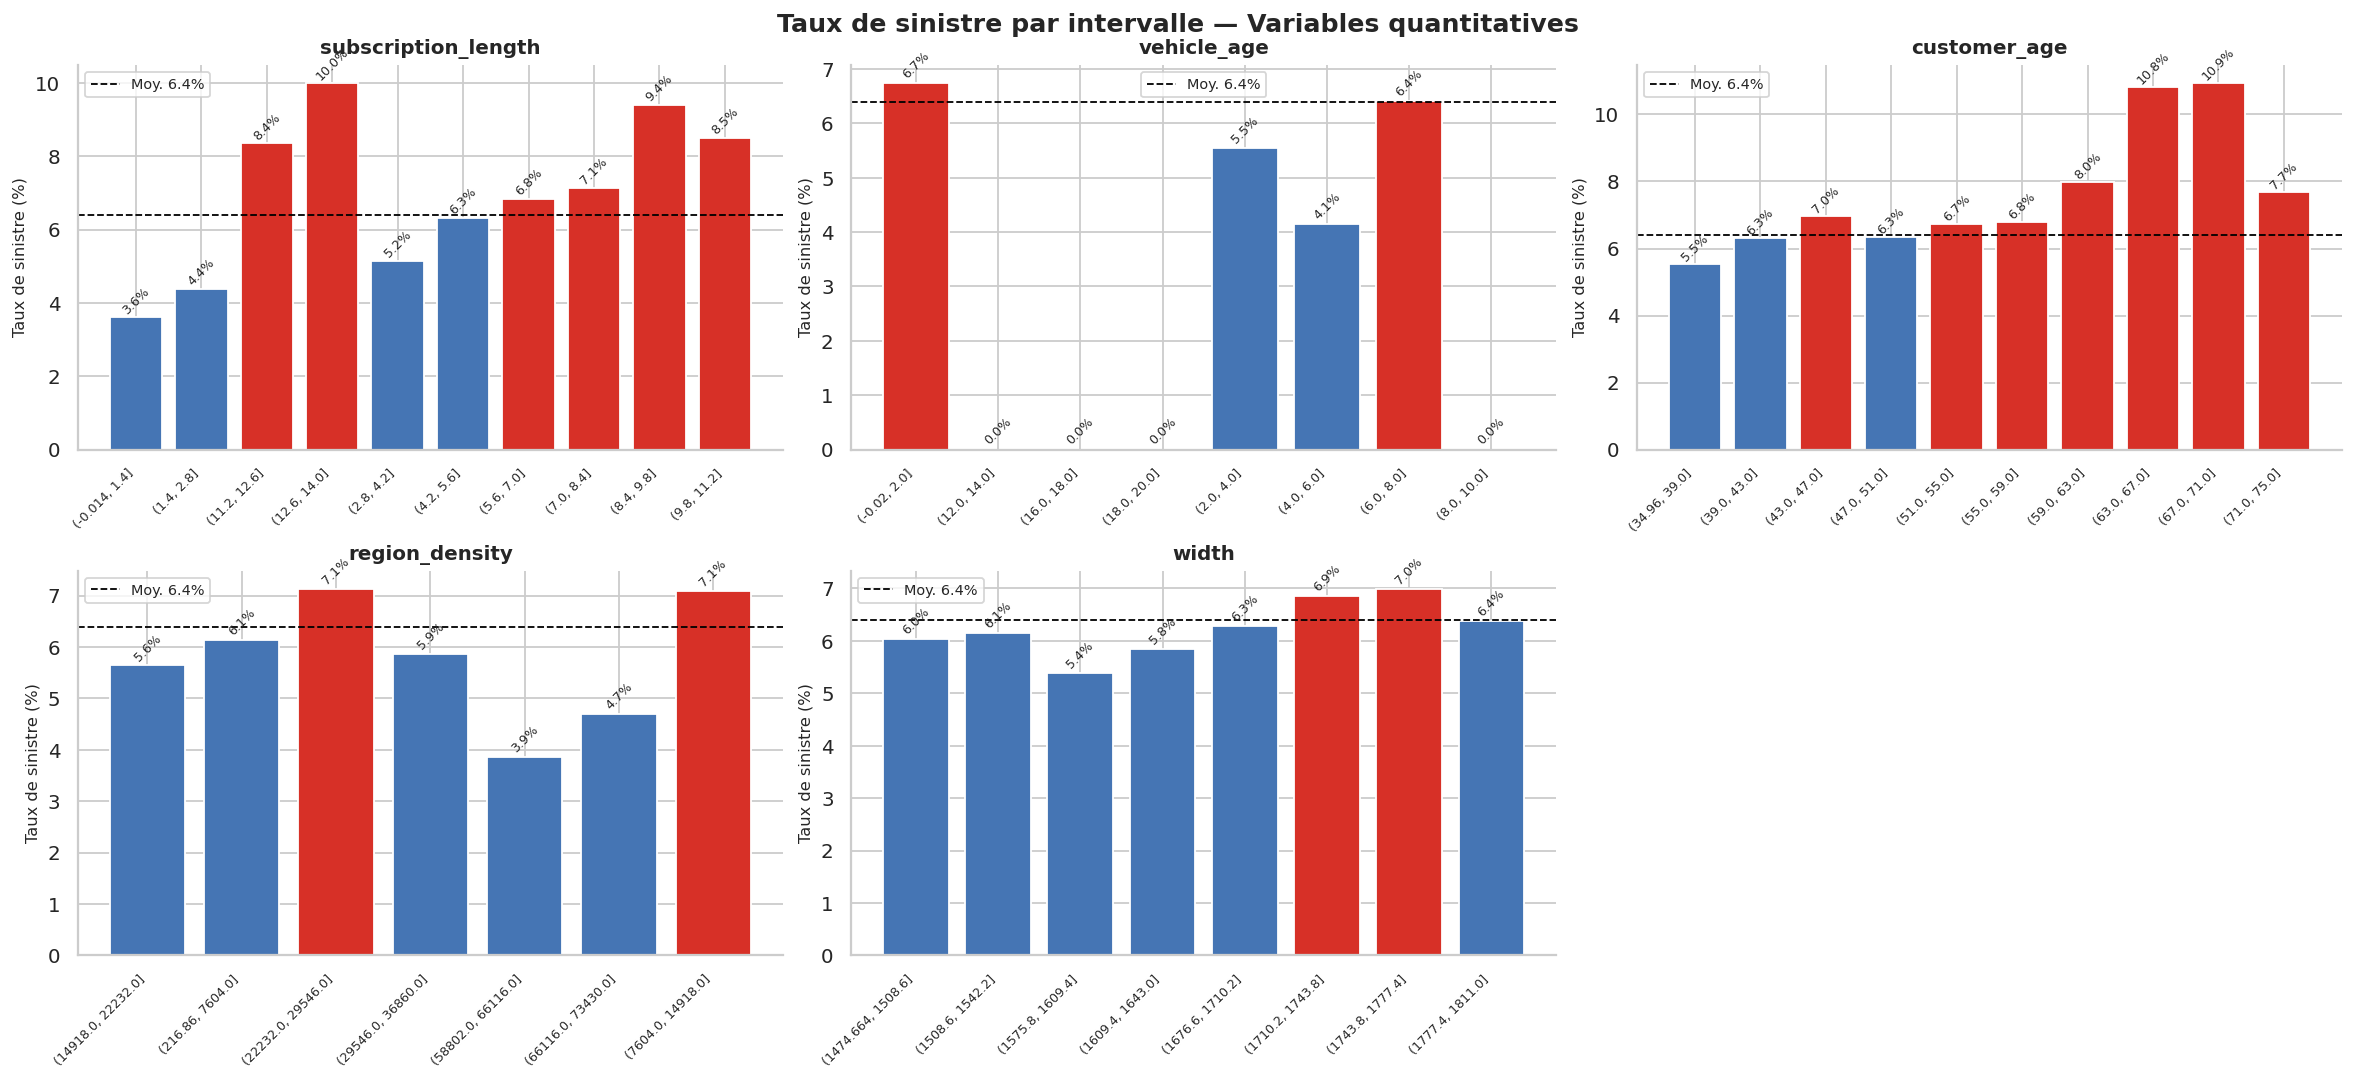

In [17]:
# ── FIGURE — Taux de sinistre par intervalle (variables quantitatives) ────
summary_quant_plot = summary_quant[summary_quant["Intervalle"] != "All"].copy()

n_vars = len(quantitative_vars)
ncols  = 3
nrows  = -(-n_vars // ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(18, nrows * 4),
                         constrained_layout=True)
axes = axes.flatten()
for i, feat in enumerate(quantitative_vars):
    ax   = axes[i]
    data = summary_quant_plot[summary_quant_plot["Variable"] == feat].copy()

    bars = ax.bar(range(len(data)), data["Taux_sinistre_%"],
                  color=["#d73027" if v >= mean_rate else "#4575b4"
                         for v in data["Taux_sinistre_%"]])
    # ligne moyenne globale
    ax.axhline(mean_rate, color="black", linestyle="--",
               linewidth=1, label=f"Moy. {mean_rate:.1f}%")
    # valeurs sur les barres
    for bar, val in zip(bars, data["Taux_sinistre_%"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f"{val:.1f}%", ha="center", fontsize=7, rotation=45)
    # labels intervalles sur x
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data["Intervalle"], rotation=45,
                       ha="right", fontsize=7)

    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_ylabel("Taux de sinistre (%)", fontsize=9)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Taux de sinistre par intervalle — Variables quantitatives",
             fontsize=14, fontweight="bold", y=1.02)
plt.show()

<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> `subscription_length` présente une relation **croissante et quasi monotone** avec le taux de sinistre, ce qui en fait la variable la plus structurante. Pour les autres variables, les écarts à la moyenne sont plus modestes et parfois irréguliers ; certains intervalles sont peu peuplés, ce qui justifie leur regroupement à l'étape suivante.
</div>

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">9. Construction des classes de risque</h2>
</div>

Le regroupement des modalités consiste à transformer chaque variable en un petit nombre de classes **homogènes en risque** et **suffisamment peuplées**. C'est une pratique standard en tarification, pour trois raisons :

- **Stabilité** : les classes rares produisent des estimations volatiles ; les regrouper réduit la variance des coefficients.
- **Interprétabilité** : chaque classe reçoit un effet unique, directement lisible dans une grille tarifaire.
- **Prise en compte des non-linéarités** : la discrétisation permet à un modèle linéaire en logit de capter des relations non monotones.

Les seuils ont été fixés à partir des taux de sinistre observés en section 8.2 :

| Variable | Classes construites |
| :--- | :--- |
| `subscription_length` | 6 classes, de [0 ; 1,4] à > 11,2 |
| `vehicle_age` | ]0 ; 1 an], ]1 ; 2 ans], > 2 ans |
| `customer_age` | ≤ 39, 39–43, 43–47, 47–51, > 51 ans |
| `region_density` | Faible, moyenne, forte densité |
| `width` | Étroit, normal, large, très large |
| `region_code` | 22 codes régionaux regroupés en 5 zones (R1 à R5) |
| Équipements binaires et `cylinder` | Modalités conservées et renommées |

In [18]:
# ── REGROUPEMENT AVEC LABELS SIGNIFICATIFS ────────────────────────────────

df_grouped = df_raw.copy()

df_grouped['subscription_length_grp'] = pd.cut(
    df_raw['subscription_length'],
    bins=[-np.inf, 1.4, 4.2, 7.0, 9.8, 11.2, np.inf],
    labels=['[0-1.4]','(1.4-4.2]','(4.2-7.0]',
            '(7.0-9.8]','(9.8-11.2]','>11.2']
)

df_grouped['vehicle_age_grp'] = df_raw['vehicle_age'].apply(
    lambda v: ']0-1 an]'  if v <= 1
         else ']1-2 ans]' if v <= 2
         else '>2 ans'
)

df_grouped['customer_age_grp'] = pd.cut(
    df_raw['customer_age'],
    bins=[-np.inf, 39.0, 43.0, 47.0, 51.0, np.inf],
    labels=['(-inf,39]','(39-43]','(43-47]','(47-51]','>51']
)

df_grouped['region_density_grp'] = pd.cut(
    df_raw['region_density'],
    bins=[-np.inf, 7604.0, 14918.0, np.inf],
    labels=['Faible_densite','Densite_moyenne','Forte_densite']
)

df_grouped['width_grp'] = pd.cut(
    df_raw['width'],
    bins=[-np.inf, 1515, 1695, 1755, np.inf],
    labels=['Etroit', 'Normal', 'Large', 'Tres_large']
)                                                              # ← parenthèse en trop supprimée

for col in ['is_adjustable_steering','is_front_fog_lights',
            'is_brake_assist','is_driver_seat_height_adjustable']:
    df_grouped[f'{col}_grp'] = df_raw[col].map({'No':'Non','Yes':'Oui'})

df_grouped['cylinder_grp'] = df_raw['cylinder'].astype(str).map(  # ← sorti de la boucle
    {'3':'3_cylindres','4':'4_cylindres'}
)

df_grouped['region_code_grp'] = (
    df_raw['region_code'].str.upper().str.strip()
    .map({
        'C8' : 'R1',
        'C2' : 'R2', 'C15': 'R2', 'C16': 'R2',
        'C17': 'R2', 'C18': 'R2', 'C20': 'R2', 'C22': 'R2',
        'C1' : 'R3', 'C3' : 'R3', 'C4' : 'R3', 'C6' : 'R3',
        'C11': 'R4', 'C12': 'R4', 'C13': 'R4',
        'C14': 'R4', 'C19': 'R4',
        'C5' : 'R5', 'C7' : 'R5', 'C9' : 'R5',
        'C10': 'R5', 'C21': 'R5',
    })
    .fillna('Autre')
)

# ── AFFICHAGE ──────────────────────────────────────────────────────────────
GRP_COLS = [
    'subscription_length_grp','vehicle_age_grp','customer_age_grp',
    'region_density_grp','width_grp','is_adjustable_steering_grp',
    'cylinder_grp','is_front_fog_lights_grp','is_brake_assist_grp',
    'is_driver_seat_height_adjustable_grp','region_code_grp',
]

MEAN_RATE = df_raw[TARGET].mean() * 100
SEP = "═" * 68

for col in GRP_COLS:
    grp = (df_grouped.groupby(col, observed=True)[TARGET]
                     .value_counts().unstack(fill_value=0)
                     .reindex(columns=[0, 1], fill_value=0))
    grp.columns       = ['Count_0', 'Count_1']
    grp['Total']      = grp.sum(axis=1)
    grp['Taux_%']     = (grp['Count_1'] / grp['Total'] * 100).round(2)
    grp['vs_Moyenne'] = (grp['Taux_%'] - MEAN_RATE).round(2).apply(
                            lambda x: f"+{x:.2f}%" if x > 0 else f"{x:.2f}%")
    print(f"\n{SEP}")
    print(f"  {col}")
    print(f"  Moy. globale : {MEAN_RATE:.2f}%")
    print(f"{SEP}")
    print(grp.sort_index().to_string())


════════════════════════════════════════════════════════════════════
  subscription_length_grp
  Moy. globale : 6.40%
════════════════════════════════════════════════════════════════════
                         Count_0  Count_1  Total  Taux_% vs_Moyenne
subscription_length_grp                                            
[0-1.4]                    11517      431  11948    3.61     -2.79%
(1.4-4.2]                  10962      547  11509    4.75     -1.65%
(4.2-7.0]                   9259      652   9911    6.58     +0.18%
(7.0-9.8]                   6450      582   7032    8.28     +1.88%
(9.8-11.2]                  9145      850   9995    8.50     +2.10%
>11.2                       7511      686   8197    8.37     +1.97%

════════════════════════════════════════════════════════════════════
  vehicle_age_grp
  Moy. globale : 6.40%
════════════════════════════════════════════════════════════════════
                 Count_0  Count_1  Total  Taux_% vs_Moyenne
vehicle_age_grp             

<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> Le regroupement fait apparaître des écarts de risque nets et interprétables :<br>• `subscription_length` : le taux passe de **3,61 %** pour les contrats les plus récents à **8,50 %** pour la classe (9,8 ; 11,2], soit un rapport de 2,4 ;<br>• `vehicle_age` : les véhicules de plus de 2 ans sont moins sinistrés (**5,48 %** contre 6,75 % pour ceux de moins d'un an) ;<br>• `region_code` : la zone R5 est nettement moins risquée (**5,35 %**) que la zone R1 (**6,99 %**) ;<br>• `customer_age` : le risque croît modérément avec l'âge, de 5,54 % (≤ 39 ans) à 7,13 % (> 51 ans).
</div>

La base finale `df_final` ne conserve que l'identifiant, les 11 variables regroupées et la cible. Elle est exportée au format CSV pour garantir la reproductibilité des étapes de modélisation.

In [19]:
GRP_COLS = [
    'subscription_length_grp','vehicle_age_grp','customer_age_grp',
    'region_density_grp','width_grp','is_adjustable_steering_grp',
    'cylinder_grp','is_front_fog_lights_grp','is_brake_assist_grp',
    'is_driver_seat_height_adjustable_grp','region_code_grp',
]

df_final = pd.concat([
    df_raw[['policy_id']].reset_index(drop=True),
    df_grouped[GRP_COLS].reset_index(drop=True),
    df_raw[[TARGET]].reset_index(drop=True),
], axis=1)

df_final.to_csv("df_final_grouped.csv", index=False)
print(f"Taux sinistre   : {df_final[TARGET].mean()*100:.2f}%")
print(f"\nTypes :\n{df_final.dtypes.value_counts()}")
display(df_final.head())



Taux sinistre   : 6.40%

Types :
object      8
category    1
category    1
category    1
category    1
int64       1
Name: count, dtype: int64


,policy_id,subscription_length_grp,vehicle_age_grp,customer_age_grp,region_density_grp,width_grp,is_adjustable_steering_grp,cylinder_grp,is_front_fog_lights_grp,is_brake_assist_grp,is_driver_seat_height_adjustable_grp,region_code_grp,claim_status
0,POL045360,(7.0-9.8],]1-2 ans],(39-43],Densite_moyenne,Tres_large,Oui,4_cylindres,Oui,Oui,Oui,R1,0
1,POL016745,(7.0-9.8],]1-2 ans],"(-inf,39]",Forte_densite,Normal,Oui,4_cylindres,Oui,Non,Oui,R2,0
2,POL007194,(7.0-9.8],]0-1 an],(43-47],Densite_moyenne,Tres_large,Oui,4_cylindres,Oui,Oui,Oui,R1,0
3,POL018146,(4.2-7.0],]0-1 an],(43-47],Forte_densite,Etroit,Non,3_cylindres,Non,Non,Non,R5,0
4,POL049011,(9.8-11.2],]0-1 an],>51,Faible_densite,Large,Oui,4_cylindres,Non,Non,Non,R4,0


<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">10. Choix des modalités de référence</h2>
</div>

Dans une régression logistique sur variables catégorielles, chaque variable est représentée par des indicatrices, **à l'exception d'une modalité de référence**. Les coefficients des autres modalités s'interprètent alors comme des écarts par rapport à cette référence.

**Règle retenue** : pour chaque variable, la référence est la modalité présentant le **taux de sinistre observé le plus élevé**, calculé ainsi :

$$\text{Taux}_{k} = \frac{\text{Nombre de sinistres dans la modalité } k}{\text{Nombre de polices dans la modalité } k} \times 100$$

Ce choix, courant en pratique actuarielle, offre une lecture directe : un *odds ratio* inférieur à 1 indique une modalité moins risquée que le profil de référence. Il faut cependant noter que ce classement est **univarié** : une fois les autres variables prises en compte, certaines modalités peuvent présenter un effet supérieur à la référence.

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# IDENTIFIER LA MODALITÉ DE RÉFÉRENCE (le grand taux de sinistre)

GRP_COLS = [
    'subscription_length_grp', 'vehicle_age_grp', 'customer_age_grp',
    'region_density_grp', 'width_grp', 'is_adjustable_steering_grp',
    'cylinder_grp', 'is_front_fog_lights_grp', 'is_brake_assist_grp',
    'is_driver_seat_height_adjustable_grp', 'region_code_grp',
]
references = {}
rows_ref   = []
for col in GRP_COLS:
    taux = (df_final.groupby(col, observed=True)[TARGET]
                    .mean().mul(100).round(2))
    ref = taux.idxmax()                            
    references[col] = ref
    for mod, t in taux.items():
        rows_ref.append({"Variable": col, "Modalité": mod,
                         "Taux_%": t, "Référence": " REF" if mod == ref else ""})

df_ref = pd.DataFrame(rows_ref)
print("MODALITÉS DE RÉFÉRENCE SÉLECTIONNÉES\n")
print(df_ref.to_string(index=False))

MODALITÉS DE RÉFÉRENCE SÉLECTIONNÉES

                            Variable        Modalité  Taux_% Référence
             subscription_length_grp         [0-1.4]    3.61          
             subscription_length_grp       (1.4-4.2]    4.75          
             subscription_length_grp       (4.2-7.0]    6.58          
             subscription_length_grp       (7.0-9.8]    8.28          
             subscription_length_grp      (9.8-11.2]    8.50       REF
             subscription_length_grp           >11.2    8.37          
                     vehicle_age_grp          >2 ans    5.48          
                     vehicle_age_grp        ]0-1 an]    6.75       REF
                     vehicle_age_grp       ]1-2 ans]    6.70          
                    customer_age_grp       (-inf,39]    5.54          
                    customer_age_grp         (39-43]    6.30          
                    customer_age_grp         (43-47]    6.97          
                    customer_age_grp   

<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> Les références retenues sont : (9,8 ; 11,2] pour `subscription_length`, ]0 ; 1 an] pour `vehicle_age`, > 51 ans pour `customer_age`, densité moyenne pour `region_density`, *Large* pour `width`, 4 cylindres pour `cylinder`, *Oui* pour les quatre équipements et R1 pour `region_code`. Toutes les références correspondent à des classes bien peuplées (plus de 9 000 polices), ce qui garantit des comparaisons stables.
</div>

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">11. Encodage et formulation du modèle logistique</h2>
</div>

### 11.1 Le modèle de régression logistique

La régression logistique modélise le logarithme de la cote (*log-odds*) du sinistre comme une combinaison linéaire des variables explicatives :

$$\log\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n$$

où $P = \mathbb{P}(\text{claim\_status} = 1 \mid X)$. La probabilité s'obtient par la fonction sigmoïde, qui ramène tout score réel dans l'intervalle $]0 ; 1[$ :

$$P = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \dots + \beta_n X_n)}}$$

**Interprétation des coefficients.** Pour une indicatrice de modalité, $e^{\beta_j}$ est l'**odds ratio** : le facteur par lequel la cote du sinistre est multipliée pour cette modalité, par rapport à la référence, toutes choses égales par ailleurs.

| Valeur | Lecture |
| :--- | :--- |
| $\beta_j > 0$ (OR > 1) | Modalité plus risquée que la référence |
| $\beta_j = 0$ (OR = 1) | Aucun écart avec la référence |
| $\beta_j < 0$ (OR < 1) | Modalité moins risquée que la référence |

### 11.2 Pourquoi exclure la modalité de référence

Si toutes les indicatrices d'une variable étaient conservées, leur somme vaudrait toujours 1. Avec la variable `cylinder_grp` par exemple :

$$\text{3cyl} + \text{4cyl} = 1 \quad \Rightarrow \quad \beta_0 + \beta_1 \cdot \text{3cyl} + \beta_2 \cdot \text{4cyl} = (\beta_0 + \beta_2) + (\beta_1 - \beta_2) \cdot \text{3cyl}$$

Une infinité de combinaisons $(\beta_0, \beta_1, \beta_2)$ produit alors les mêmes prédictions : les coefficients ne sont pas identifiables (**piège des variables indicatrices**, ou multicolinéarité parfaite). En supprimant l'indicatrice de la référence (ici 4 cylindres), le modèle devient :

$$\log\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1 \cdot \text{3cyl}$$

- pour un véhicule 4 cylindres (référence), le logit vaut $\beta_0$ ;
- pour un véhicule 3 cylindres, il vaut $\beta_0 + \beta_1$, et $\beta_1$ mesure exactement l'écart entre les deux.

### 11.3 Construction de la matrice explicative

Chaque variable est encodée en *one-hot* (`get_dummies`), puis l'indicatrice de sa référence est supprimée. Les noms de colonnes sont nettoyés (crochets, symboles, espaces) pour être compatibles avec XGBoost.

In [21]:
# BLOC 2 — GET_DUMMIES() EN EXCLUANT LA MODALITÉ DE RÉFÉRENCE
X_raw = df_final[GRP_COLS].copy()
dummies_list = []
for col in GRP_COLS:
    ref = references[col]
    dummies = pd.get_dummies(X_raw[col], prefix=col, dtype=int)
    ref_col = f"{col}_{ref}"
    if ref_col in dummies.columns:
        dummies = dummies.drop(columns=[ref_col])   # exclut la référence
    dummies_list.append(dummies)

X = pd.concat(dummies_list, axis=1)
X.columns = (X.columns
               .str.replace("[", "(", regex=False)
               .str.replace("]", ")", regex=False)
               .str.replace("<", "inf", regex=False)
               .str.replace(">", "sup", regex=False)
               .str.replace(" ", "_", regex=False)
               .str.replace(",", "-", regex=False))
y = df_final[TARGET].astype(int)

print(f"\n{'═'*60}")
print(f"  Shape : {X.shape[0]:,} observations  ×  {X.shape[1]} colonnes")
print(f"{'─'*60}")
for col in GRP_COLS:
    cols_var = [c.replace(col + "_", "") for c in X.columns if c.startswith(col + "_")]
    ref      = references[col]
    print(f"  {col:<45} {len(cols_var)} col  |  réf : {ref}")
print(f"{'═'*60}")



════════════════════════════════════════════════════════════
  Shape : 58,592 observations  ×  25 colonnes
────────────────────────────────────────────────────────────
  subscription_length_grp                       5 col  |  réf : (9.8-11.2]
  vehicle_age_grp                               2 col  |  réf : ]0-1 an]
  customer_age_grp                              4 col  |  réf : >51
  region_density_grp                            2 col  |  réf : Densite_moyenne
  width_grp                                     3 col  |  réf : Large
  is_adjustable_steering_grp                    1 col  |  réf : Oui
  cylinder_grp                                  1 col  |  réf : 4_cylindres
  is_front_fog_lights_grp                       1 col  |  réf : Oui
  is_brake_assist_grp                           1 col  |  réf : Oui
  is_driver_seat_height_adjustable_grp          1 col  |  réf : Oui
  region_code_grp                               4 col  |  réf : R1
══════════════════════════════════════════════════

<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> La matrice explicative `X` compte **58 592 observations × 25 indicatrices**, issues des 11 variables regroupées. Elle est commune aux trois modèles, ce qui garantit une comparaison à données identiques.
</div>

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">12. Modélisation</h2>
</div>

### 12.1 Partition apprentissage / test

Les données sont partagées en un échantillon d'apprentissage (70 %) et un échantillon de test (30 %). La partition est **stratifiée** sur la cible afin que le taux de sinistre soit identique dans les deux échantillons.

In [22]:
# BLOC 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Taux sinistre Train : {y_train.mean()*100:.2f}%")
print(f"Taux sinistre Test  : {y_test.mean()*100:.2f}%")

Train : (41014, 25) | Test : (17578, 25)
Taux sinistre Train : 6.40%
Taux sinistre Test  : 6.39%


Le taux de sinistre est conservé (6,40 % en apprentissage, 6,39 % en test) : l'échantillon de test est représentatif du portefeuille.

### 12.2 Régression logistique pénalisée

La régression logistique est optimisée par recherche sur grille :

- **Paramètre `C`** : inverse de l'intensité de la régularisation (plus `C` est petit, plus la pénalisation est forte) ;
- **Pénalité L1 (Lasso)** : peut annuler certains coefficients et réalise ainsi une sélection de variables ;
- **Pénalité L2 (Ridge)** : réduit tous les coefficients sans les annuler ;
- `class_weight="balanced"` compense le déséquilibre en donnant plus de poids aux polices sinistrées.

In [23]:
# BLOC 3 — RÉGRESSION LOGISTIQUE (sortie = probabilité)
param_grid = {
    "C"      : [0.1, 0.5, 1, 5, 10, 50],   # ← C plus grands, pas 0.001
    "penalty": ["l1", "l2"],
    "solver" : ["liblinear"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    param_grid,
    cv      = cv,
    scoring = "roc_auc",                    # ← AUC pour la sélection du meilleur modèle
    n_jobs  = -1,
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
# ── Prédiction = PROBABILITÉ ─────────────────────────────────────────────────
y_proba = best_model.predict_proba(X_test)[:, 1]
# ── Métriques de régression ──────────────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_proba)
mse  = mean_squared_error (y_test, y_proba)
rmse = np.sqrt(mse)
auc_lr = roc_auc_score(y_test, y_proba)
brier_lr = brier_score_loss(y_test, y_proba)    
y_proba_lr = y_proba

print(f"\nMeilleurs paramètres : {grid.best_params_}")
print(f"\n── Métriques de Régression ──")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"AUC-ROC     : {auc_lr:.4f}")                  # ← ajout
print(f"Brier Score : {brier_lr:.4f}   (0 = parfait)")
pred_df = pd.DataFrame({
    "Réel"       : y_test.values,
    "P(sinistre)": y_proba.round(4),
}).reset_index(drop=True)

print(f"\nAperçu des probabilités prédites :\n{pred_df.head(10).to_string(index=False)}")
print(f"\nDistribution des probabilités prédites :")
print(pd.cut(y_proba, bins=5).value_counts().sort_index())



Meilleurs paramètres : {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}

── Métriques de Régression ──
MAE  : 0.4842
MSE  : 0.2429
RMSE : 0.4928
AUC-ROC     : 0.6122
Brier Score : 0.2429   (0 = parfait)

Aperçu des probabilités prédites :
 Réel  P(sinistre)
    0       0.5528
    0       0.5384
    0       0.5250
    0       0.5464
    0       0.5408
    0       0.6372
    0       0.5034
    0       0.6480
    0       0.4082
    0       0.5083

Distribution des probabilités prédites :
(0.239, 0.325]     908
(0.325, 0.411]    3433
(0.411, 0.497]    4230
(0.497, 0.582]    6172
(0.582, 0.668]    2835
Name: count, dtype: int64


<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> La configuration retenue est une **pénalité L1 avec C = 0,1**, soit une régularisation forte. Le modèle obtient une **AUC-ROC de 0,612** sur l'échantillon de test : il classe correctement une police sinistrée au-dessus d'une non sinistrée dans 61 % des cas, contre 50 % pour un classement aléatoire.<br><br>Les probabilités prédites se concentrent entre 0,24 et 0,67, autour de 0,5. Ce n'est pas le taux réel du portefeuille (6,4 %) : la pondération `class_weight="balanced"` fait apprendre le modèle comme si les deux classes étaient de même taille. Ces sorties doivent donc être lues comme des **scores de risque relatif** et non comme des probabilités calibrées ; pour la même raison, MAE, MSE et Brier Score (≈ 0,24) mesurent surtout ce décalage et ne sont pas le critère de comparaison principal.
</div>

### 12.3 Coefficients et odds ratios

Les coefficients $\beta$ et les odds ratios $e^{\beta}$ mesurent l'effet de chaque classe par rapport à la modalité de référence de sa variable, toutes choses égales par ailleurs.

In [24]:
# BLOC 4 — COEFFICIENTS β (interprétation)
coef_df = (pd.DataFrame({
                "Variable"   : X.columns,
                "Coefficient": best_model.coef_[0].round(4),
                "Odds Ratio" : np.exp(best_model.coef_[0]).round(4),
            })
            .sort_values("Coefficient", ascending=False)
            .reset_index(drop=True))

print("\nCOEFFICIENTS β — triés par ordre décroissant\n")
print(coef_df.to_string(index=False))


COEFFICIENTS β — triés par ordre décroissant

                                Variable  Coefficient  Odds Ratio
is_driver_seat_height_adjustable_grp_Non       0.1237      1.1317
                      region_code_grp_R3       0.1016      1.1070
                        width_grp_Etroit       0.0924      1.0968
         subscription_length_grp_sup11.2       0.0295      1.0300
                customer_age_grp_(43-47)       0.0252      1.0255
                      region_code_grp_R2       0.0220      1.0222
                 is_brake_assist_grp_Non       0.0176      1.0177
                customer_age_grp_(39-43)       0.0000      1.0000
       subscription_length_grp_(7.0-9.8)       0.0000      1.0000
             is_front_fog_lights_grp_Non       0.0000      1.0000
                cylinder_grp_3_cylindres       0.0000      1.0000
                      region_code_grp_R4      -0.0011      0.9989
                        width_grp_Normal      -0.0229      0.9773
                    width_grp

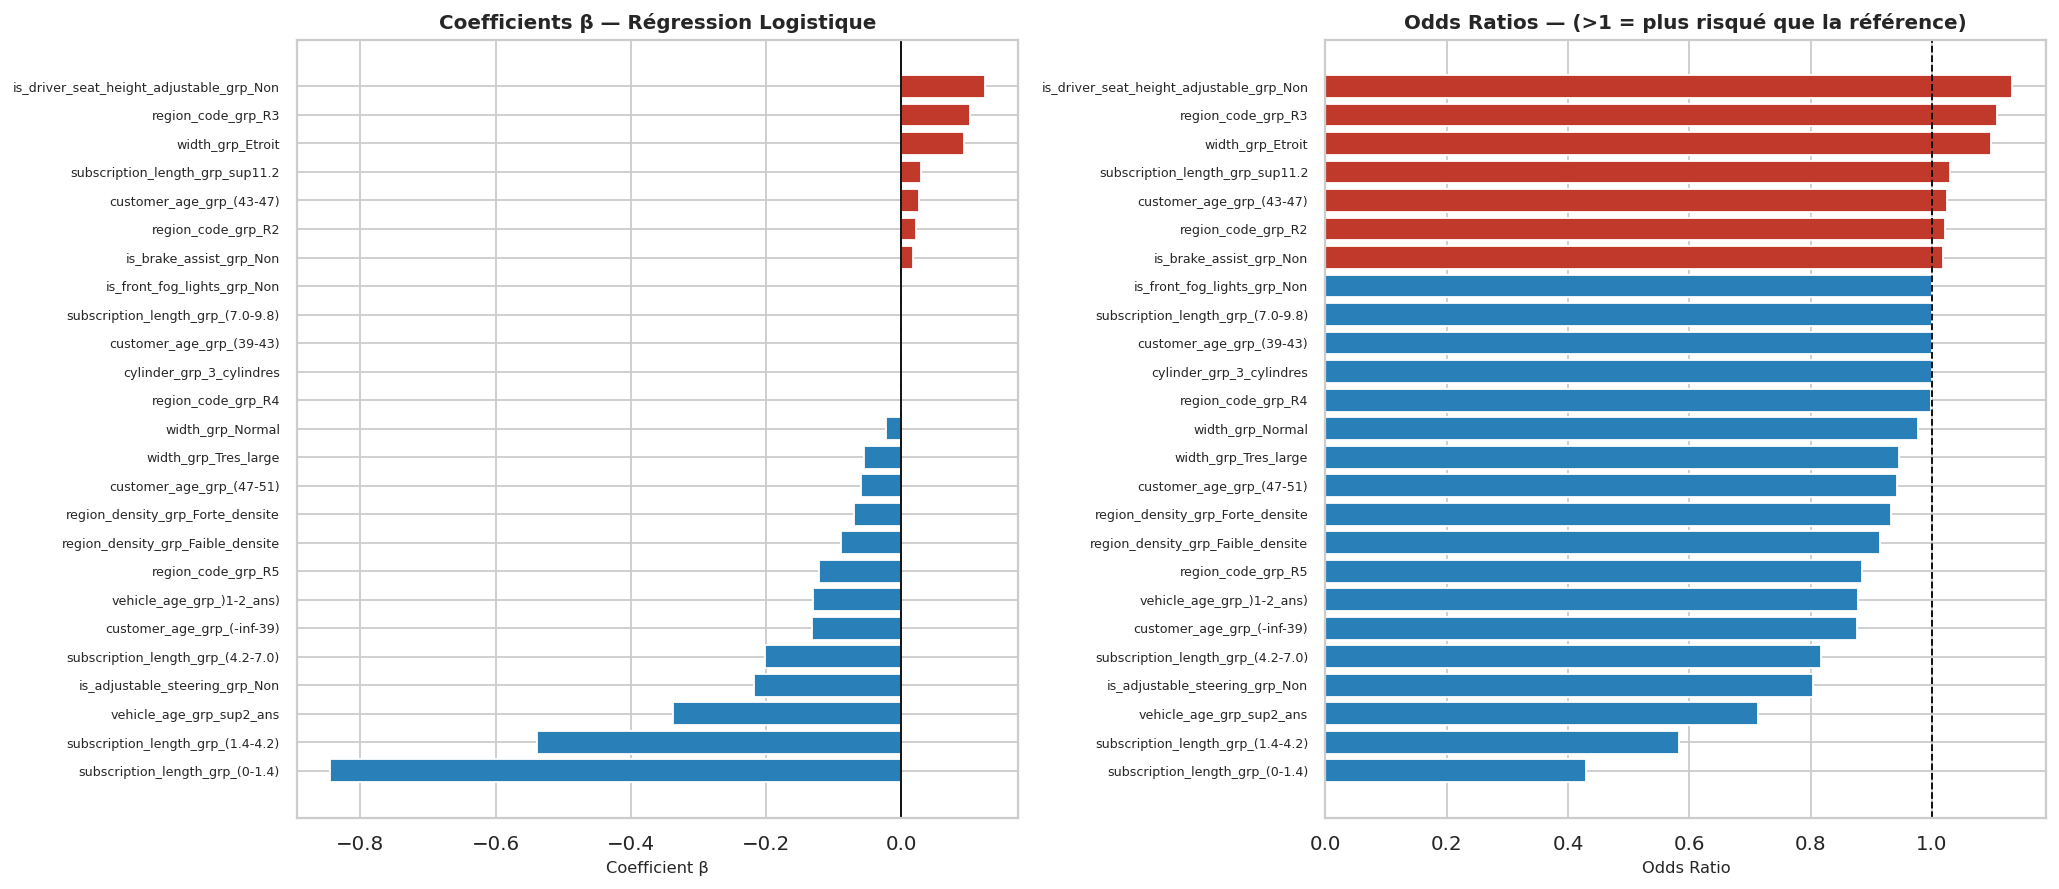

In [25]:
# BLOC 5 — VISUALISATION DES COEFFICIENTS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax   = axes[0]
data = coef_df.sort_values("Coefficient")
colors = ["#c0392b" if v > 0 else "#2980b9" for v in data["Coefficient"]]
ax.barh(data["Variable"], data["Coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Coefficients β — Régression Logistique", fontweight="bold")
ax.set_xlabel("Coefficient β")
ax.tick_params(axis="y", labelsize=7)

ax   = axes[1]
data = coef_df.sort_values("Odds Ratio")
colors = ["#c0392b" if v > 1 else "#2980b9" for v in data["Odds Ratio"]]
ax.barh(data["Variable"], data["Odds Ratio"], color=colors, edgecolor="white")
ax.axvline(1, color="black", linewidth=1, linestyle="--")
ax.set_title("Odds Ratios — (>1 = plus risqué que la référence)", fontweight="bold")
ax.set_xlabel("Odds Ratio")
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

#### Lecture des résultats

**Facteurs protecteurs (OR < 1)** — classes significativement moins risquées que leur référence :

| Classe | β | Odds ratio | Lecture |
| :--- | :---: | :---: | :--- |
| Ancienneté du contrat [0 ; 1,4] | −0,845 | 0,43 | Cote du sinistre réduite de 57 % par rapport à (9,8 ; 11,2] |
| Ancienneté du contrat (1,4 ; 4,2] | −0,539 | 0,58 | Réduction de 42 % |
| Véhicule de plus de 2 ans | −0,338 | 0,71 | Réduction de 29 % par rapport à un véhicule de moins d'un an |
| Sans direction réglable | −0,218 | 0,80 | Réduction de 20 % |
| Ancienneté du contrat (4,2 ; 7,0] | −0,202 | 0,82 | Réduction de 18 % |
| Assuré de 39 ans ou moins | −0,132 | 0,88 | Réduction de 12 % par rapport aux plus de 51 ans |
| Zone R5 | −0,122 | 0,89 | Réduction de 11 % par rapport à R1 |

**Facteurs aggravants (OR > 1)** — effets positifs, de faible ampleur :

| Classe | β | Odds ratio |
| :--- | :---: | :---: |
| Siège conducteur non réglable en hauteur | +0,124 | 1,13 |
| Zone R3 | +0,102 | 1,11 |
| Véhicule étroit | +0,092 | 1,10 |

**Coefficients nuls.** La pénalité L1 a annulé quatre coefficients (`customer_age` 39–43, `subscription_length` (7,0 ; 9,8], absence d'antibrouillards, 3 cylindres) : ces classes n'apportent pas d'information supplémentaire une fois les autres variables prises en compte.

<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> L'**ancienneté du contrat** est de loin le facteur le plus discriminant, avec un gradient de risque monotone. Viennent ensuite l'**âge du véhicule** et, dans une moindre mesure, la zone géographique et l'âge de l'assuré.<br><br>Certains signes diffèrent de l'analyse univariée : par exemple, l'absence de réglage du siège était associée à un taux brut plus faible, mais obtient un effet positif dans le modèle. Les équipements de confort sont fortement corrélés entre eux et à la gamme du véhicule ; une fois ces effets pris en compte simultanément, leur contribution propre change. Ces coefficients, proches de zéro, doivent être interprétés avec prudence.
</div>

### 12.4 Matrice de confusion (seuil de 0,5)

La matrice de confusion croise les classes réelles et prédites en appliquant un seuil de 0,5 aux scores du modèle.

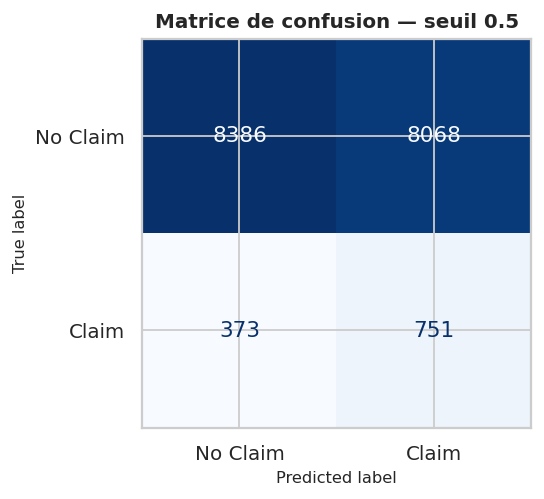

In [26]:
# BLOC 6 — MATRICE DE CONFUSION (seuil 0.5)
y_pred = (y_proba >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["No Claim", "Claim"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matrice de confusion — seuil 0.5", fontweight="bold")
plt.tight_layout()
plt.show()

Les scores étant centrés autour de 0,5, environ la moitié des polices de test (près de 9 000 sur 17 578) dépassent ce seuil et sont classées « sinistre ». Le modèle détecte ainsi davantage de sinistres qu'un modèle non pondéré, au prix d'un nombre élevé de faux positifs. Le seuil de 0,5 est une convention : en pratique, il doit être choisi selon le coût relatif d'un sinistre non détecté et d'une fausse alerte, par exemple à partir de la courbe ROC présentée en section 13.

### 12.5 XGBoost

XGBoost construit séquentiellement des arbres de décision, chacun corrigeant les erreurs des précédents (*gradient boosting*). Le déséquilibre est traité par `scale_pos_weight`, égal au rapport entre non-sinistres et sinistres (≈ 14,6). La grille explore le nombre d'arbres, leur profondeur, le taux d'apprentissage et les taux d'échantillonnage.

In [27]:
param_grid_xgb = {
    "n_estimators"     : [100, 300, 500],
    "max_depth"        : [3, 5, 7],
    "learning_rate"    : [0.01, 0.05, 0.1],
    "subsample"        : [0.7, 1.0],
    "colsample_bytree" : [0.7, 1.0],
}

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()   # ≈ 14.6

grid_xgb = GridSearchCV(
    XGBClassifier(
        scale_pos_weight = scale_pos_weight,
        eval_metric      = "auc",
        random_state     = 42,
        n_jobs           = -1,
    ),
    param_grid_xgb,
    cv      = cv,
    scoring = "roc_auc",
    n_jobs  = -1,
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

# ── Prédiction = PROBABILITÉ ──────────────────────────────────────────────────
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# ── Métriques ─────────────────────────────────────────────────────────────────
mae_xgb   = mean_absolute_error(y_test, y_proba_xgb)
mse_xgb   = mean_squared_error (y_test, y_proba_xgb)
rmse_xgb  = np.sqrt(mse_xgb)
auc_xgb   = roc_auc_score      (y_test, y_proba_xgb)
brier_xgb = brier_score_loss   (y_test, y_proba_xgb)

print(f"Meilleurs paramètres XGBoost : {grid_xgb.best_params_}")
print(f"\n── Métriques de Régression — XGBoost ──")
print(f"MAE         : {mae_xgb:.4f}")
print(f"MSE         : {mse_xgb:.4f}")
print(f"RMSE        : {rmse_xgb:.4f}")
print(f"AUC-ROC     : {auc_xgb:.4f}")
print(f"Brier Score : {brier_xgb:.4f}   (0 = parfait)")

pred_xgb = pd.DataFrame({
    "Réel"       : y_test.values,
    "P(sinistre)": y_proba_xgb.round(4),
}).reset_index(drop=True)

print(f"\nAperçu des probabilités prédites :\n{pred_xgb.head(10).to_string(index=False)}")
print(f"\nDistribution des probabilités prédites :")
print(pd.cut(y_proba_xgb, bins=5).value_counts().sort_index())

Meilleurs paramètres XGBoost : {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}

── Métriques de Régression — XGBoost ──
MAE         : 0.4818
MSE         : 0.2408
RMSE        : 0.4907
AUC-ROC     : 0.6252
Brier Score : 0.2408   (0 = parfait)

Aperçu des probabilités prédites :
 Réel  P(sinistre)
    0       0.5549
    0       0.5568
    0       0.5389
    0       0.5143
    0       0.5509
    0       0.6088
    0       0.4596
    0       0.5735
    0       0.4318
    0       0.5200

Distribution des probabilités prédites :
(0.169, 0.259]     565
(0.259, 0.348]    1592
(0.348, 0.437]    1734
(0.437, 0.527]    6207
(0.527, 0.616]    7480
Name: count, dtype: int64


<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> La configuration optimale combine des **arbres peu profonds** (`max_depth = 3`), un **taux d'apprentissage faible** (0,01) et 300 arbres : un modèle très régularisé, cohérent avec la faiblesse du signal. XGBoost atteint une **AUC-ROC de 0,625**, la meilleure des trois modèles.
</div>

### 12.6 Random Forest

La forêt aléatoire agrège un grand nombre d'arbres construits sur des échantillons *bootstrap* et des sous-ensembles aléatoires de variables. Elle réduit la variance par moyennage et capte naturellement les interactions entre variables.

In [28]:
# BLOC RANDOM FOREST — Hyperparameter Tuning + Métriques de Régression
param_grid_rf = {
    "n_estimators" : [100, 300, 500],
    "max_depth"    : [5, 10, None],
    "max_features" : ["sqrt", "log2"],
    "min_samples_leaf" : [1, 5, 10],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(
        class_weight = "balanced",
        random_state = 42,
        n_jobs       = -1,
    ),
    param_grid_rf,
    cv      = cv,
    scoring = "roc_auc",
    n_jobs  = -1,
)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

# ── Prédiction = PROBABILITÉ ──────────────────────────────────────────────────
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

# ── Métriques ─────────────────────────────────────────────────────────────────
mae_rf   = mean_absolute_error(y_test, y_proba_rf)
mse_rf   = mean_squared_error (y_test, y_proba_rf)
rmse_rf  = np.sqrt(mse_rf)
auc_rf   = roc_auc_score      (y_test, y_proba_rf)
brier_rf = brier_score_loss   (y_test, y_proba_rf)

print(f"Meilleurs paramètres Random Forest : {grid_rf.best_params_}")
print(f"\n── Métriques de Régression — Random Forest ──")
print(f"MAE         : {mae_rf:.4f}")
print(f"MSE         : {mse_rf:.4f}")
print(f"RMSE        : {rmse_rf:.4f}")
print(f"AUC-ROC     : {auc_rf:.4f}")
print(f"Brier Score : {brier_rf:.4f}   (0 = parfait)")

pred_rf = pd.DataFrame({
    "Réel"       : y_test.values,
    "P(sinistre)": y_proba_rf.round(4),
}).reset_index(drop=True)

print(f"\nAperçu des probabilités prédites :\n{pred_rf.head(10).to_string(index=False)}")
print(f"\nDistribution des probabilités prédites :")
print(pd.cut(y_proba_rf, bins=5).value_counts().sort_index())

Meilleurs paramètres Random Forest : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 500}

── Métriques de Régression — Random Forest ──
MAE         : 0.4852
MSE         : 0.2398
RMSE        : 0.4897
AUC-ROC     : 0.6170
Brier Score : 0.2398   (0 = parfait)

Aperçu des probabilités prédites :
 Réel  P(sinistre)
    0       0.5466
    0       0.5444
    0       0.5252
    0       0.5066
    0       0.5400
    0       0.5723
    0       0.4914
    0       0.5537
    0       0.4497
    0       0.5150

Distribution des probabilités prédites :
(0.261, 0.331]     593
(0.331, 0.399]    1604
(0.399, 0.468]    3305
(0.468, 0.537]    7874
(0.537, 0.606]    4202
Name: count, dtype: int64


<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> La grille retient **500 arbres de profondeur 5** avec au moins 10 observations par feuille : ici encore, la sélection privilégie des modèles contraints. La Random Forest atteint une **AUC-ROC de 0,617** et obtient le Brier Score le plus faible (0,240).
</div>

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">13. Comparaison des modèles</h2>
</div>

Les trois modèles sont comparés sur le même échantillon de test. L'AUC-ROC, indépendante du seuil de décision et peu sensible au déséquilibre, constitue le critère principal.

── COMPARAISON DES MODÈLES ──

                        MAE     MSE    RMSE  AUC-ROC  Brier Score
Modèle                                                           
Logistic Regression  0.4842  0.2429  0.4928   0.6122       0.2429
XGBoost              0.4818  0.2408  0.4907   0.6252       0.2408
Random Forest        0.4852  0.2398  0.4897   0.6170       0.2398

 Meilleur AUC   : XGBoost
 Meilleur MAE   : XGBoost
 Meilleur Brier : Random Forest


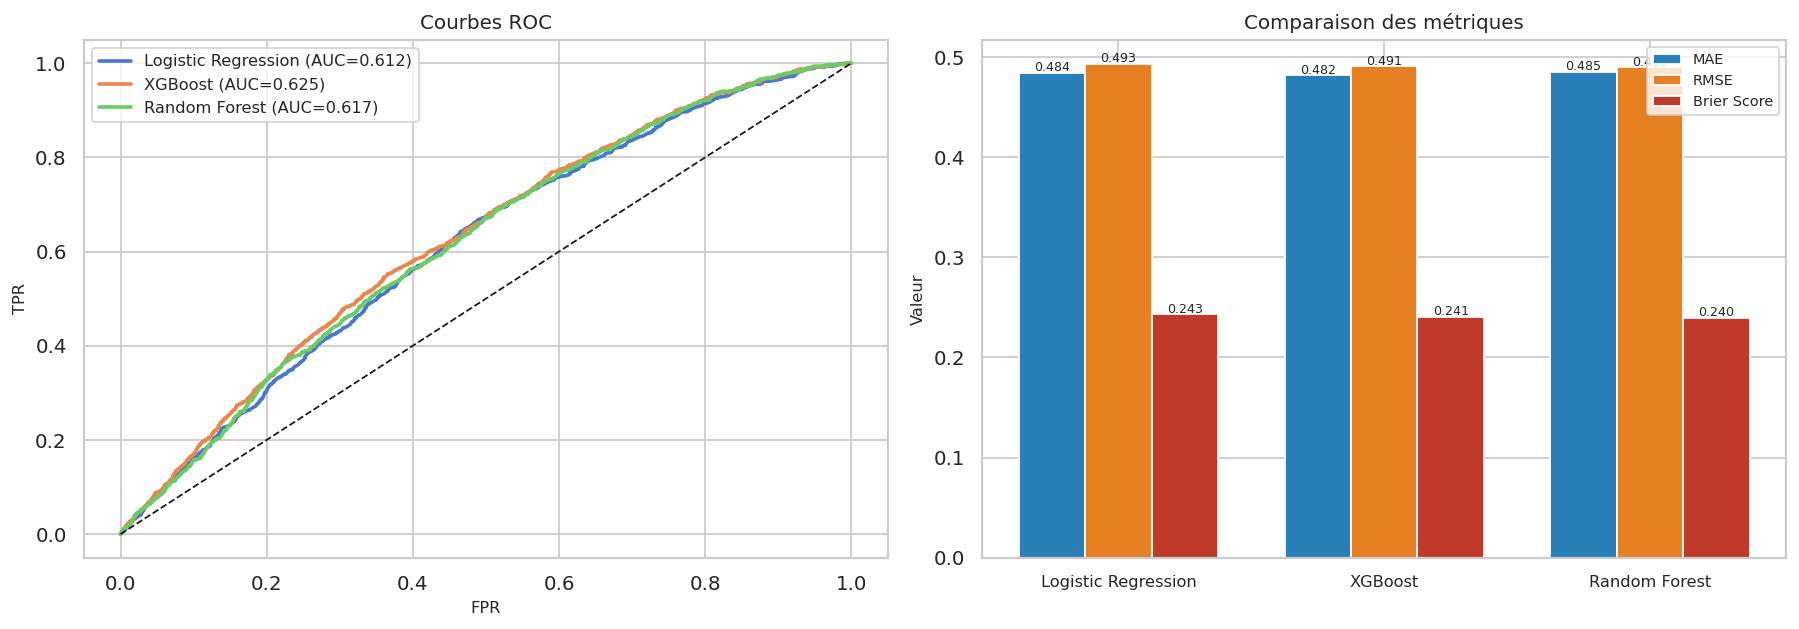

In [29]:
# BLOC COMPARAISON — LR vs XGBoost vs Random Forest
from sklearn.metrics import roc_curve
comparison = pd.DataFrame({
    "Modèle"      : ["Logistic Regression", "XGBoost", "Random Forest"],
    "MAE"         : [mae,    mae_xgb,    mae_rf],
    "MSE"         : [mse,    mse_xgb,    mse_rf],
    "RMSE"        : [rmse,   rmse_xgb,   rmse_rf],
    "AUC-ROC"     : [auc_lr,    auc_xgb,    auc_rf],
    "Brier Score" : [brier_lr,  brier_xgb,  brier_rf],
}).round(4).set_index("Modèle")

print("── COMPARAISON DES MODÈLES ──\n")
print(comparison.to_string())
print(f"\n Meilleur AUC   : {comparison['AUC-ROC'].idxmax()}")
print(f" Meilleur MAE   : {comparison['MAE'].idxmin()}")
print(f" Meilleur Brier : {comparison['Brier Score'].idxmin()}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
ax = axes[0]
for name, y_proba in [("Logistic Regression", y_proba_lr),
                       ("XGBoost",             y_proba_xgb),
                       ("Random Forest",       y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val     = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_val:.3f})")
ax.plot([0,1],[0,1], "k--", linewidth=1)
ax.set(xlabel="FPR", ylabel="TPR", title="Courbes ROC")
ax.legend(fontsize=9)

# Barplot métriques
ax  = axes[1]
x   = np.arange(3)
w   = 0.25
metrics_plot = ["MAE", "RMSE", "Brier Score"]
colors       = ["#2980b9", "#e67e22", "#c0392b"]
for i, (metric, color) in enumerate(zip(metrics_plot, colors)):
    vals = comparison[metric].values
    bars = ax.bar(x + i*w, vals, w, label=metric, color=color, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{v:.3f}", ha="center", fontsize=7)
ax.set_xticks(x + w)
ax.set_xticklabels(comparison.index, fontsize=9)
ax.set(title="Comparaison des métriques", ylabel="Valeur")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

| Modèle | AUC-ROC | Brier Score | Points forts | Limites |
| :--- | :---: | :---: | :--- | :--- |
| Régression logistique | 0,612 | 0,243 | Coefficients interprétables, grille tarifaire directe | Ne capte pas les interactions |
| **XGBoost** | **0,625** | 0,241 | Meilleur pouvoir discriminant | Interprétation moins directe |
| Random Forest | 0,617 | **0,240** | Robuste, peu sensible au sur-apprentissage | Interprétation moins directe |

<div style="border-left:4px solid #1f3a5f; background:#f4f6f9; padding:12px 16px; margin-top:8px;">
<b>À retenir.</b> **XGBoost** offre la meilleure discrimination, mais l'écart avec la régression logistique est faible (**+0,013 point d'AUC**). Les courbes ROC des trois modèles sont très proches. Avec des variables regroupées en classes, l'essentiel du signal disponible est déjà capté par un modèle linéaire : les interactions exploitées par les méthodes ensemblistes apportent un gain limité. Dans un contexte actuariel, où la justification des tarifs est exigée, la **régression logistique reste un choix pertinent** pour un coût de performance marginal.
</div>

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">14. Discussion et limites</h2>
</div>

**Un pouvoir prédictif modéré.** Avec une AUC comprise entre 0,61 et 0,63, les modèles discriminent mieux que le hasard, mais de façon limitée. Ce niveau est cohérent avec les faibles tailles d'effet mesurées en section 7 : les variables disponibles décrivent surtout le contrat et le véhicule, alors que la sinistralité dépend largement du **comportement de conduite** (kilométrage, usage, historique de sinistres, bonus-malus), absent de la base.

**Des probabilités non calibrées.** La pondération des classes améliore la détection des sinistres mais déplace les probabilités prédites vers 0,5. Pour un usage tarifaire, où la probabilité doit correspondre à une fréquence réelle, une étape de **calibration** (régression de Platt ou régression isotonique) serait nécessaire. Les métriques MAE, MSE et Brier Score doivent être relues après cette calibration.

**Une référence choisie sur un critère univarié.** Les modalités de référence ont été choisies d'après les taux bruts. Une fois toutes les variables prises en compte, certaines modalités ressortent plus risquées que leur référence (odds ratios supérieurs à 1). Ce choix n'affecte pas les prédictions, mais il nuance la lecture « tous les effets sont protecteurs ».

**Des effets d'équipement à interpréter avec prudence.** Les équipements de confort (siège réglable, direction réglable, antibrouillards) sont probablement des marqueurs indirects de la gamme du véhicule plutôt que des causes du risque. Leur effet propre, faible et parfois de signe contraire à l'analyse univariée, reflète leurs corrélations mutuelles.

**Absence d'exposition.** La base ne précise pas la durée de couverture de chaque police. En pratique actuarielle, la fréquence se modélise habituellement par un modèle de Poisson avec terme d'exposition ; la relation croissante entre ancienneté du contrat et sinistre pourrait en partie refléter une durée d'observation plus longue.

<div style="background:#1f3a5f; padding:14px 22px; border-radius:6px; margin:10px 0 18px 0;">
  <h2 style="color:#ffffff; margin:0; font-family:Georgia, serif; font-weight:normal;">15. Conclusion et perspectives</h2>
</div>

Ce travail visait à prédire la survenance d'un sinistre automobile et à identifier les facteurs qui expliquent les écarts de risque entre assurés. La démarche a combiné tests statistiques, construction de classes de risque, régression logistique interprétable et modèles ensemblistes.

### Principaux résultats

- **Le risque de sinistre est diffus.** Aucune variable n'explique seule la sinistralité : les associations sont statistiquement significatives mais d'intensité faible (V de Cramér < 0,02, |r| ≤ 0,18).
- **L'ancienneté du contrat est le facteur dominant.** Le taux de sinistre varie de 3,6 % à 8,5 % selon les classes, et l'odds ratio des contrats les plus récents est de 0,43 par rapport à la référence.
- **L'âge du véhicule, la zone géographique et l'âge de l'assuré** complètent la segmentation : les véhicules de plus de 2 ans, la zone R5 et les assurés de moins de 39 ans présentent un risque plus faible.
- **Les trois modèles ont des performances proches** (AUC de 0,612 à 0,625). XGBoost est le plus discriminant, mais la régression logistique en est très proche tout en offrant une interprétation directe des effets.

### Réponse à la problématique

Les caractéristiques disponibles permettent de **hiérarchiser les assurés selon leur risque** et d'identifier des facteurs tarifaires clairs, au premier rang desquels l'ancienneté du contrat et l'âge du véhicule. Elles ne suffisent cependant pas à prédire avec précision la survenance d'un sinistre individuel : une part importante du risque relève de facteurs non observés dans la base.

### Perspectives

1. **Calibrer les probabilités** (Platt, isotonique) pour obtenir des fréquences directement utilisables en tarification.
2. **Optimiser le seuil de décision** selon une fonction de coût métier plutôt que le seuil par défaut de 0,5.
3. **Enrichir les données** avec des variables comportementales (kilométrage, historique de sinistres, coefficient bonus-malus) et l'exposition de chaque police.
4. **Explorer un modèle de fréquence de Poisson** (GLM avec terme d'exposition), standard de la tarification automobile, puis le compléter par un modèle de sévérité pour estimer la prime pure.
5. **Interpréter les modèles ensemblistes** à l'aide des valeurs SHAP, afin de concilier performance et explicabilité.